In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
DATASET_ZIP = r"/content/drive/MyDrive/Datasets/final_dataset_v2.zip"

In [3]:
# ============================================================
# CELL 1: INSTALL BASIC DEPENDENCIES
# ============================================================

# PyYAML -> read/write data.yaml
# pandas  -> metrics/tables
# matplotlib -> plotting/visual inspection
# pillow -> image handling

!pip install -q pyyaml pandas matplotlib pillow

print("Basic dependencies installed.")

Basic dependencies installed.


In [4]:
# ============================================================
# CELL 3: PROJECT CONFIGURATION
# ============================================================

from pathlib import Path



# ============================================================
# GOOGLE DRIVE
# ============================================================

# Change this to the folder where your dataset ZIP exists.
#
# Example:
#
# /content/drive/MyDrive/AI_Project/final_dataset.zip
#
DRIVE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/Datasets"
)


# ============================================================
# DATASET ZIP
# ============================================================

DATASET_ZIP = (
    DRIVE_PROJECT_DIR
    / "final_dataset_v2.zip"
)


# ============================================================
# COLAB LOCAL STORAGE
# ============================================================
#
# We copy/extract the dataset to /content because local
# Colab storage is much faster than repeatedly reading images
# directly from Google Drive.
#
DATASET_DIR = Path(
    "/content/dataset"
)

EXTRACTED_DATASET_DIR = (
    DATASET_DIR / "extracted"
)


# ============================================================
# YOLOV5
# ============================================================

YOLOV5_DIR = Path(
    "/content/yolov5"
)


# ============================================================
# MODEL
# ============================================================

# Common YOLOv5 models:
#
# yolov5n.pt -> Nano
# yolov5s.pt -> Small
# yolov5m.pt -> Medium
# yolov5l.pt -> Large
# yolov5x.pt -> Extra Large
#
# Start with yolov5s.pt.

MODEL_WEIGHTS = "yolov5s.pt"


# ============================================================
# TRAINING HYPERPARAMETERS
# ============================================================

# ------------------------------------------------------------
# Number of epochs
# ------------------------------------------------------------

EPOCHS = 20


# ------------------------------------------------------------
# Batch size
# ------------------------------------------------------------
#
# Start with 16.
#
# If CUDA out-of-memory:
#
# 16 -> 8 -> 4
#
BATCH_SIZE = 32


# ------------------------------------------------------------
# Image size
# ------------------------------------------------------------

IMG_SIZE = 640


# ------------------------------------------------------------
# DataLoader workers
# ------------------------------------------------------------
#
# Colab usually handles 2-8.
#
WORKERS = 4


# ============================================================
# OPTIMIZER
# ============================================================

OPTIMIZER = "SGD"


# ============================================================
# CUSTOM HYPERPARAMETERS
# ============================================================
#
# For your first baseline, I recommend False.
#
# Once your baseline works, enable custom hyperparameters.
#
USE_CUSTOM_HYP = False

HYP_FILE = (
    Path("/content")
    / "yolov5_custom_hyp.yaml"
)


# ============================================================
# DATA AUGMENTATION / TRAINING OPTIONS
# ============================================================

CACHE_IMAGES = False

RECTANGULAR_TRAINING = False

SAVE_PERIOD = -1


# ============================================================
# RANDOM SEED
# ============================================================

SEED = 42


# ============================================================
# EVALUATION
# ============================================================

CONF_THRESHOLD = 0.001

IOU_THRESHOLD = 0.6


# ============================================================
# DRIVE OUTPUT
# ============================================================

DRIVE_RESULTS_DIR = (
    DRIVE_PROJECT_DIR
    / "yolov5_results"
)


print("Configuration loaded.")
print()
print("Dataset ZIP:")
print(DATASET_ZIP)
print()
print("Model:", MODEL_WEIGHTS)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Image size:", IMG_SIZE)
print("Workers:", WORKERS)

Configuration loaded.

Dataset ZIP:
/content/drive/MyDrive/Datasets/final_dataset_v2.zip

Model: yolov5s.pt
Epochs: 20
Batch size: 32
Image size: 640
Workers: 4


In [5]:
# ============================================================
# CELL 4: CHECK DATASET ZIP
# ============================================================

if not DATASET_ZIP.exists():

    raise FileNotFoundError(
        f"Dataset ZIP was not found:\n\n"
        f"{DATASET_ZIP}"
    )

print(
    "Dataset ZIP found:"
)

print(
    DATASET_ZIP.resolve()
)

print(
    "\nFile size:"
)

size_mb = (
    DATASET_ZIP.stat().st_size
    / (1024 * 1024)
)

print(
    f"{size_mb:.2f} MB"
)

Dataset ZIP found:
/content/drive/MyDrive/Datasets/final_dataset_v2.zip

File size:
478.10 MB


In [6]:
# ============================================================
# CELL 5: EXTRACT DATASET
# ============================================================

import zipfile
import shutil


# ------------------------------------------------------------
# Remove previous extraction
# ------------------------------------------------------------

if EXTRACTED_DATASET_DIR.exists():

    print(
        "Removing previous extracted dataset..."
    )

    shutil.rmtree(
        EXTRACTED_DATASET_DIR
    )


EXTRACTED_DATASET_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Extract
# ------------------------------------------------------------

print(
    "Extracting dataset..."
)

with zipfile.ZipFile(
    DATASET_ZIP,
    "r"
) as zip_file:

    zip_file.extractall(
        EXTRACTED_DATASET_DIR
    )


print(
    "\nExtraction completed."
)

Extracting dataset...

Extraction completed.


In [7]:
# ============================================================
# CELL 6: FIND DATASET ROOT
# ============================================================

def find_dataset_root(base_dir):

    # --------------------------------------------------------
    # Direct root
    # --------------------------------------------------------

    direct_yaml = (
        base_dir / "data.yaml"
    )

    if direct_yaml.exists():

        return base_dir


    # --------------------------------------------------------
    # Search recursively
    # --------------------------------------------------------

    yaml_files = list(
        base_dir.rglob("data.yaml")
    )

    if not yaml_files:

        raise FileNotFoundError(
            "Could not find data.yaml "
            "inside the extracted dataset."
        )


    # Prefer a root that has train/images
    for yaml_file in yaml_files:

        root = yaml_file.parent

        if (
            root
            / "train"
            / "images"
        ).exists():

            return root


    return yaml_files[0].parent


dataset_root = find_dataset_root(
    EXTRACTED_DATASET_DIR
)


print(
    "Dataset root:"
)

print(
    dataset_root.resolve()
)

Dataset root:
/content/dataset/extracted/final_dataset


In [8]:
# ============================================================
# CELL 7: VALIDATE DATASET STRUCTURE
# ============================================================

required_directories = [

    dataset_root / "train" / "images",
    dataset_root / "train" / "labels",

    dataset_root / "val" / "images",
    dataset_root / "val" / "labels",

    dataset_root / "test" / "images",
    dataset_root / "test" / "labels",
]


print(
    "Checking dataset directories...\n"
)


for directory in required_directories:

    if not directory.exists():

        raise FileNotFoundError(
            f"Missing required directory:\n"
            f"{directory.resolve()}"
        )

    print(
        f"✓ {directory.relative_to(dataset_root)}"
    )


print(
    "\nDataset structure is valid."
)

Checking dataset directories...

✓ train/images
✓ train/labels
✓ val/images
✓ val/labels
✓ test/images
✓ test/labels

Dataset structure is valid.


In [9]:
# ============================================================
# CELL 8: READ DATA.YAML
# ============================================================

import yaml


DATA_YAML_PATH = (
    dataset_root / "data.yaml"
)


with open(
    DATA_YAML_PATH,
    "r",
    encoding="utf-8"
) as file:

    data_config = yaml.safe_load(
        file
    )


print("=" * 60)
print("DATA.YAML")
print("=" * 60)

print(
    yaml.safe_dump(
        data_config,
        sort_keys=False
    )
)


# ============================================================
# CLASSES
# ============================================================

NC = int(
    data_config["nc"]
)

NAMES = data_config["names"]


if isinstance(NAMES, dict):

    class_names = [
        NAMES[i]
        for i in sorted(
            NAMES,
            key=lambda x: int(x)
        )
    ]

else:

    class_names = list(
        NAMES
    )


# ------------------------------------------------------------
# Verify class count
# ------------------------------------------------------------

if len(class_names) != NC:

    raise ValueError(
        f"Class count mismatch:\n"
        f"nc = {NC}\n"
        f"names = {class_names}"
    )


print(
    "\nClass mapping:"
)

for class_id, class_name in enumerate(
    class_names
):

    print(
        f"  {class_id}: {class_name}"
    )


print(
    f"\nTotal classes: {NC}"
)

DATA.YAML
path: C:\Users\INDUS LAPTOP\Downloads\Project files\Final_merging\final_dataset
train: train/images
val: val/images
test: test/images
nc: 3
names:
- mango
- strawberry
- tomato


Class mapping:
  0: mango
  1: strawberry
  2: tomato

Total classes: 3


In [10]:
# ============================================================
# CELL 9: DATASET STATISTICS
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}


def count_images(directory):

    return sum(

        1

        for file in directory.rglob("*")

        if (
            file.is_file()
            and file.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    )


print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)


dataset_statistics = {}


for split in [
    "train",
    "val",
    "test"
]:

    images_dir = (
        dataset_root
        / split
        / "images"
    )

    labels_dir = (
        dataset_root
        / split
        / "labels"
    )


    image_count = count_images(
        images_dir
    )

    label_count = len(
        list(
            labels_dir.glob(
                "*.txt"
            )
        )
    )


    dataset_statistics[
        split
    ] = {
        "images": image_count,
        "labels": label_count,
    }


    print(
        f"{split.upper():5} | "
        f"Images: {image_count:6} | "
        f"Labels: {label_count:6}"
    )

DATASET STATISTICS
TRAIN | Images:   6300 | Labels:   6300
VAL   | Images:   1350 | Labels:   1350
TEST  | Images:   1350 | Labels:   1350


In [11]:
# ============================================================
# CELL 10: CLASS DISTRIBUTION
# ============================================================

from collections import Counter


def get_class_distribution(
    labels_dir
):

    counter = Counter()

    label_files = list(
        labels_dir.glob("*.txt")
    )

    for label_file in label_files:

        with open(
            label_file,
            "r",
            encoding="utf-8"
        ) as file:

            for line in file:

                parts = line.strip().split()

                if not parts:
                    continue

                try:

                    class_id = int(
                        float(parts[0])
                    )

                    counter[class_id] += 1

                except ValueError:

                    pass

    return counter


print("=" * 60)
print("OBJECT / ANNOTATION DISTRIBUTION")
print("=" * 60)


for split in [
    "train",
    "val",
    "test"
]:

    labels_dir = (
        dataset_root
        / split
        / "labels"
    )

    distribution = (
        get_class_distribution(
            labels_dir
        )
    )

    print(
        f"\n{split.upper()}"
    )

    for class_id in range(NC):

        count = distribution[
            class_id
        ]

        class_name = (
            class_names[class_id]
        )

        print(
            f"  {class_id}: "
            f"{class_name:<15} "
            f"{count}"
        )

OBJECT / ANNOTATION DISTRIBUTION

TRAIN
  0: mango           4950
  1: strawberry      4352
  2: tomato          5391

VAL
  0: mango           1155
  1: strawberry      975
  2: tomato          1189

TEST
  0: mango           1045
  1: strawberry      904
  2: tomato          1083


In [12]:
# ============================================================
# CELL 11: CLONE YOLOV5
# ============================================================

import subprocess
import shutil


if YOLOV5_DIR.exists():

    train_file = (
        YOLOV5_DIR / "train.py"
    )

    requirements_file = (
        YOLOV5_DIR
        / "requirements.txt"
    )

    # --------------------------------------------------------
    # Check whether repository is complete
    # --------------------------------------------------------

    if (
        train_file.exists()
        and requirements_file.exists()
    ):

        print(
            "YOLOv5 already exists:"
        )

        print(
            YOLOV5_DIR.resolve()
        )

    else:

        print(
            "Incomplete YOLOv5 folder detected."
        )

        shutil.rmtree(
            YOLOV5_DIR
        )


if not YOLOV5_DIR.exists():

    print(
        "Cloning YOLOv5..."
    )

    result = subprocess.run(

        [
            "git",
            "clone",

            "https://github.com/"
            "ultralytics/yolov5.git",

            str(YOLOV5_DIR)
        ],

        check=False
    )

    if result.returncode != 0:

        raise RuntimeError(
            "YOLOv5 cloning failed."
        )


print(
    "\nYOLOv5 ready:"
)

print(
    YOLOV5_DIR.resolve()
)

Cloning YOLOv5...

YOLOv5 ready:
/content/yolov5


In [13]:
# ============================================================
# CELL 12: INSTALL YOLOV5 DEPENDENCIES
# ============================================================

import sys
import subprocess
from pathlib import Path


# ------------------------------------------------------------
# Locate requirements.txt
# ------------------------------------------------------------

YOLOV5_DIR = Path("/content/yolov5")

requirements_file = (
    YOLOV5_DIR / "requirements.txt"
)


# ------------------------------------------------------------
# Check YOLOv5
# ------------------------------------------------------------

if not YOLOV5_DIR.exists():

    raise FileNotFoundError(
        f"YOLOv5 directory does not exist:\n"
        f"{YOLOV5_DIR}"
    )


if not requirements_file.exists():

    raise FileNotFoundError(
        f"YOLOv5 requirements.txt not found:\n"
        f"{requirements_file}"
    )


print(
    "Installing YOLOv5 dependencies..."
)

print(
    f"\nRequirements file:\n"
    f"{requirements_file}"
)


# ------------------------------------------------------------
# Install
# ------------------------------------------------------------

result = subprocess.run(

    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(requirements_file)
    ],

    check=False
)


# ------------------------------------------------------------
# Check result
# ------------------------------------------------------------

if result.returncode != 0:

    raise RuntimeError(
        "YOLOv5 dependency installation failed."
    )


print(
    "\n✓ YOLOv5 dependencies installed successfully."
)

Installing YOLOv5 dependencies...

Requirements file:
/content/yolov5/requirements.txt

✓ YOLOv5 dependencies installed successfully.


In [14]:
# ============================================================
# CELL 13: VERIFY COLAB GPU
# ============================================================

import torch


print("=" * 60)
print("GPU CHECK")
print("=" * 60)


print(
    "\nPyTorch version:"
)

print(
    torch.__version__
)


print(
    "\nCUDA available:"
)

print(
    torch.cuda.is_available()
)


if not torch.cuda.is_available():

    raise RuntimeError(
        "\nCUDA GPU is not available.\n\n"
        "Go to:\n"
        "Runtime -> Change runtime type -> GPU\n"
        "and restart the runtime."
    )


GPU_NAME = (
    torch.cuda.get_device_name(0)
)


GPU_MEMORY = (
    torch.cuda.get_device_properties(0)
    .total_memory
    / (1024 ** 3)
)


print(
    "\nGPU:"
)

print(
    GPU_NAME
)


print(
    "\nGPU memory:"
)

print(
    f"{GPU_MEMORY:.2f} GB"
)


print(
    "\n✓ CUDA GPU is ready."
)

GPU CHECK

PyTorch version:
2.11.0+cu128

CUDA available:
True

GPU:
Tesla T4

GPU memory:
14.56 GB

✓ CUDA GPU is ready.


In [15]:
# ============================================================
# CELL 14: CUSTOM HYPERPARAMETERS
# ============================================================

# These are YOLOv5 hyperparameters.
#
# For the first baseline:
#
#     USE_CUSTOM_HYP = False
#
# Then YOLOv5 uses its default hyperparameters.
#
# When you start experiments, change the values below and
# set:
#
#     USE_CUSTOM_HYP = True
# ============================================================


hyp = {

    # --------------------------------------------------------
    # Learning rate
    # --------------------------------------------------------

    "lr0": 0.01,

    "lrf": 0.01,


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    "momentum": 0.937,

    "weight_decay": 0.0005,


    # --------------------------------------------------------
    # Warmup
    # --------------------------------------------------------

    "warmup_epochs": 3.0,

    "warmup_momentum": 0.8,

    "warmup_bias_lr": 0.1,


    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    "box": 0.05,

    "cls": 0.5,

    "cls_pw": 1.0,

    "obj": 1.0,

    "obj_pw": 1.0,


    # --------------------------------------------------------
    # IoU / anchor
    # --------------------------------------------------------

    "iou_t": 0.20,

    "anchor_t": 4.0,


    # --------------------------------------------------------
    # Focal loss
    # --------------------------------------------------------

    "fl_gamma": 0.0,


    # --------------------------------------------------------
    # HSV augmentation
    # --------------------------------------------------------

    "hsv_h": 0.015,

    "hsv_s": 0.7,

    "hsv_v": 0.4,


    # --------------------------------------------------------
    # Geometric augmentation
    # --------------------------------------------------------

    "degrees": 0.0,

    "translate": 0.1,

    "scale": 0.5,

    "shear": 0.0,

    "perspective": 0.0,


    # --------------------------------------------------------
    # Flip
    # --------------------------------------------------------

    "flipud": 0.0,

    "fliplr": 0.5,


    # --------------------------------------------------------
    # Mosaic / MixUp
    # --------------------------------------------------------

    "mosaic": 1.0,

    "mixup": 0.0,

    "copy_paste": 0.0,
}


with open(
    HYP_FILE,
    "w",
    encoding="utf-8"
) as file:

    yaml.safe_dump(
        hyp,
        file,
        sort_keys=False
    )


print(
    "Hyperparameter file:"
)

print(
    HYP_FILE.resolve()
)

Hyperparameter file:
/content/yolov5_custom_hyp.yaml


In [16]:
# ============================================================
# CELL 15: CREATE YOLOV5 DATA YAML
# ============================================================

YOLOV5_DATA_YAML = (
    dataset_root
    / "data_yolov5.yaml"
)


training_data_config = {

    "path": str(
        dataset_root.resolve()
    ),

    "train": "train/images",

    "val": "val/images",

    "test": "test/images",

    "nc": NC,

    "names": class_names,
}


with open(
    YOLOV5_DATA_YAML,
    "w",
    encoding="utf-8"
) as file:

    yaml.safe_dump(
        training_data_config,
        file,
        sort_keys=False
    )


print(
    "Created YOLOv5 data file:"
)

print(
    YOLOV5_DATA_YAML.resolve()
)


print("\nContents:\n")

print(
    yaml.safe_dump(
        training_data_config,
        sort_keys=False
    )
)

Created YOLOv5 data file:
/content/dataset/extracted/final_dataset/data_yolov5.yaml

Contents:

path: /content/dataset/extracted/final_dataset
train: train/images
val: val/images
test: test/images
nc: 3
names:
- mango
- strawberry
- tomato



In [17]:
# ============================================================
# CELL 16: PRE-TRAINING CHECK
# ============================================================

print("=" * 70)
print("FINAL PRE-TRAINING CHECK")
print("=" * 70)


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

print("\nDataset:")
print(
    dataset_root.resolve()
)


# ------------------------------------------------------------
# Classes
# ------------------------------------------------------------

print("\nClasses:")

for class_id, class_name in enumerate(
    class_names
):

    print(
        f"  {class_id}: {class_name}"
    )


# ------------------------------------------------------------
# Split counts
# ------------------------------------------------------------

print("\nDataset splits:")

for split in [
    "train",
    "val",
    "test"
]:

    images = count_images(
        dataset_root
        / split
        / "images"
    )

    print(
        f"  {split:<5}: "
        f"{images} images"
    )


# ------------------------------------------------------------
# GPU
# ------------------------------------------------------------

print("\nGPU:")

print(
    torch.cuda.get_device_name(0)
)


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\nTraining:")

print(
    f"  Model:       {MODEL_WEIGHTS}"
)

print(
    f"  Epochs:      {EPOCHS}"
)

print(
    f"  Batch size:  {BATCH_SIZE}"
)

print(
    f"  Image size:  {IMG_SIZE}"
)

print(
    f"  Workers:     {WORKERS}"
)

print(
    f"  Optimizer:   {OPTIMIZER}"
)

print(
    f"  Custom hyp:  {USE_CUSTOM_HYP}"
)


print(
    "\n✓ Ready for training."
)

FINAL PRE-TRAINING CHECK

Dataset:
/content/dataset/extracted/final_dataset

Classes:
  0: mango
  1: strawberry
  2: tomato

Dataset splits:
  train: 6300 images
  val  : 1350 images
  test : 1350 images

GPU:
Tesla T4

Training:
  Model:       yolov5s.pt
  Epochs:      20
  Batch size:  32
  Image size:  640
  Workers:     4
  Optimizer:   SGD
  Custom hyp:  False

✓ Ready for training.


In [19]:
# ============================================================
# CELL 18: TRAIN YOLOV5
# ============================================================

import subprocess
import sys


train_script = (
    YOLOV5_DIR
    / "train.py"
)


if not train_script.exists():

    raise FileNotFoundError(
        f"train.py not found:\n"
        f"{train_script.resolve()}"
    )


# ============================================================
# GPU DEVICE
# ============================================================

DEVICE = "0"


print("=" * 70)
print("STARTING YOLOV5 TRAINING")
print("=" * 70)


print(
    f"\nGPU:"
)

print(
    torch.cuda.get_device_name(0)
)


print(
    f"\nModel:      {MODEL_WEIGHTS}"
)

print(
    f"Epochs:     {EPOCHS}"
)

print(
    f"Batch:      {BATCH_SIZE}"
)

print(
    f"Image size: {IMG_SIZE}"
)


# ============================================================
# COMMAND
# ============================================================

command = [

    sys.executable,

    "-u",

    "train.py",

    "--img",
    str(IMG_SIZE),

    "--batch",
    str(BATCH_SIZE),

    "--epochs",
    str(EPOCHS),

    "--data",
    str(
        YOLOV5_DATA_YAML.resolve()
    ),

    "--weights",
    MODEL_WEIGHTS,

    "--workers",
    str(WORKERS),

    "--optimizer",
    OPTIMIZER,

    "--device",
    DEVICE,

    "--project",
    "runs/train",

    "--name",
    "fruit_detector",

    "--exist-ok",

    "--seed",
    str(SEED),
]


# ============================================================
# OPTIONAL HYPERPARAMETERS
# ============================================================

if USE_CUSTOM_HYP:

    command.extend([
        "--hyp",
        str(HYP_FILE.resolve())
    ])


# ============================================================
# OPTIONAL SETTINGS
# ============================================================

if CACHE_IMAGES:

    command.append(
        "--cache"
    )


if RECTANGULAR_TRAINING:

    command.append(
        "--rect"
    )


if SAVE_PERIOD != -1:

    command.extend([
        "--save-period",
        str(SAVE_PERIOD)
    ])


# ============================================================
# DISPLAY
# ============================================================

print(
    "\nCommand:\n"
)

print(
    " ".join(
        str(x)
        for x in command
    )
)


print(
    "\n" + "-" * 70
)

print(
    "TRAINING OUTPUT"
)

print(
    "-" * 70
)


# ============================================================
# RUN TRAINING
# ============================================================

# Important:
#
# stdout/stderr are NOT manually piped.
# This avoids the Jupyter readline problem you encountered
# on Windows.
#

result = subprocess.run(

    command,

    cwd=YOLOV5_DIR,

    check=False,

    stdout=None,

    stderr=None,
)


# ============================================================
# RESULT
# ============================================================

if result.returncode != 0:

    raise RuntimeError(
        f"\nYOLOv5 training failed.\n"
        f"Exit code: {result.returncode}"
    )


print(
    "\n✓ Training completed successfully."
)

STARTING YOLOV5 TRAINING

GPU:
Tesla T4

Model:      yolov5s.pt
Epochs:     20
Batch:      32
Image size: 640

Command:

/usr/bin/python3 -u train.py --img 640 --batch 32 --epochs 20 --data /content/dataset/extracted/final_dataset/data_yolov5.yaml --weights yolov5s.pt --workers 4 --optimizer SGD --device 0 --project runs/train --name fruit_detector --exist-ok --seed 42

----------------------------------------------------------------------
TRAINING OUTPUT
----------------------------------------------------------------------

✓ Training completed successfully.


In [20]:
# ============================================================
# CELL 19: LOCATE BEST MODEL
# ============================================================

BEST_MODEL = (
    YOLOV5_DIR
    / "runs"
    / "train"
    / "fruit_detector"
    / "weights"
    / "best.pt"
)


LAST_MODEL = (
    YOLOV5_DIR
    / "runs"
    / "train"
    / "fruit_detector"
    / "weights"
    / "last.pt"
)


if not BEST_MODEL.exists():

    raise FileNotFoundError(
        f"best.pt not found:\n"
        f"{BEST_MODEL.resolve()}"
    )


print(
    "Best model:"
)

print(
    BEST_MODEL.resolve()
)


if LAST_MODEL.exists():

    print(
        "\nLast model:"
    )

    print(
        LAST_MODEL.resolve()
    )

Best model:
/content/yolov5/runs/train/fruit_detector/weights/best.pt

Last model:
/content/yolov5/runs/train/fruit_detector/weights/last.pt


In [21]:
# ============================================================
# CELL 20: VALIDATION EVALUATION
# ============================================================

val_script = (
    YOLOV5_DIR
    / "val.py"
)


command = [

    sys.executable,

    "val.py",

    "--weights",
    str(
        BEST_MODEL.resolve()
    ),

    "--data",
    str(
        YOLOV5_DATA_YAML.resolve()
    ),

    "--img",
    str(IMG_SIZE),

    "--batch-size",
    str(BATCH_SIZE),

    # --------------------------------------------------------
    # Low confidence for PR/mAP calculation
    # --------------------------------------------------------

    "--conf-thres",
    str(CONF_THRESHOLD),

    "--iou-thres",
    str(IOU_THRESHOLD),

    "--task",
    "val",

    "--project",
    "runs/val",

    "--name",
    "validation",

    "--exist-ok",
]


print(
    "Evaluating validation set..."
)


result = subprocess.run(

    command,

    cwd=YOLOV5_DIR,

    check=False
)


if result.returncode != 0:

    raise RuntimeError(
        "Validation evaluation failed."
    )


print(
    "\n✓ Validation evaluation completed."
)

Evaluating validation set...

✓ Validation evaluation completed.


In [22]:
# ============================================================
# CELL 21: FINAL TEST EVALUATION
# ============================================================

print("=" * 70)
print("FINAL TEST EVALUATION")
print("=" * 70)


print(
    "\nIMPORTANT:"
)

print(
    "This is the unseen test set."
)

print(
    "Do not use these results to tune hyperparameters."
)


command = [

    sys.executable,

    "val.py",

    "--weights",
    str(
        BEST_MODEL.resolve()
    ),

    "--data",
    str(
        YOLOV5_DATA_YAML.resolve()
    ),

    "--img",
    str(IMG_SIZE),

    "--batch-size",
    str(BATCH_SIZE),

    "--conf-thres",
    str(CONF_THRESHOLD),

    "--iou-thres",
    str(IOU_THRESHOLD),

    "--task",
    "test",

    "--project",
    "runs/test",

    "--name",
    "final_test",

    "--exist-ok",
]


result = subprocess.run(

    command,

    cwd=YOLOV5_DIR,

    check=False
)


if result.returncode != 0:

    raise RuntimeError(
        "Final test evaluation failed."
    )


print(
    "\n✓ Final test evaluation completed."
)

FINAL TEST EVALUATION

IMPORTANT:
This is the unseen test set.
Do not use these results to tune hyperparameters.

✓ Final test evaluation completed.


In [23]:
# ============================================================
# CELL 22: TEST IMAGE INFERENCE
# ============================================================

detect_script = (
    YOLOV5_DIR
    / "detect.py"
)


TEST_IMAGES_DIR = (
    dataset_root
    / "test"
    / "images"
)


command = [

    sys.executable,

    "detect.py",

    "--weights",
    str(
        BEST_MODEL.resolve()
    ),

    "--source",
    str(
        TEST_IMAGES_DIR.resolve()
    ),

    "--img",
    str(IMG_SIZE),

    # Use a normal confidence threshold for visual
    # inspection.
    "--conf-thres",
    "0.25",

    "--project",
    "runs/detect",

    "--name",
    "test_predictions",

    "--exist-ok",
]


print(
    "Running inference on test images..."
)


result = subprocess.run(

    command,

    cwd=YOLOV5_DIR,

    check=False
)


if result.returncode != 0:

    raise RuntimeError(
        "Test inference failed."
    )


TEST_PREDICTIONS_DIR = (
    YOLOV5_DIR
    / "runs"
    / "detect"
    / "test_predictions"
)


print(
    "\nPredictions saved to:"
)

print(
    TEST_PREDICTIONS_DIR.resolve()
)

Running inference on test images...

Predictions saved to:
/content/yolov5/runs/detect/test_predictions


Prediction images found: 1350

mango_mango_merged_dataset_000001_archive_combined_418_jpg.rf.f531105006032744dda989075dc6dccd_271c171c.jpg


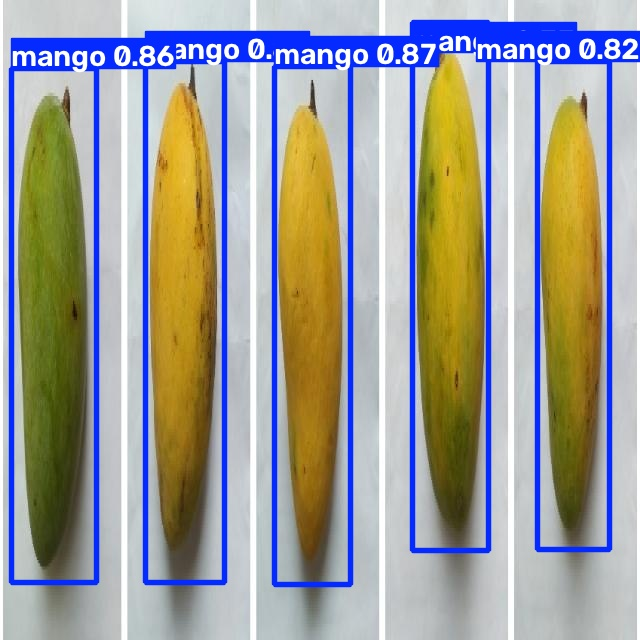


mango_mango_merged_dataset_000002_archive_324965459_1220620255328175_2390490071958184538_n_png.rf.112e74e381e1bb84f95ff71b19a03abb_dc14fa68.jpg


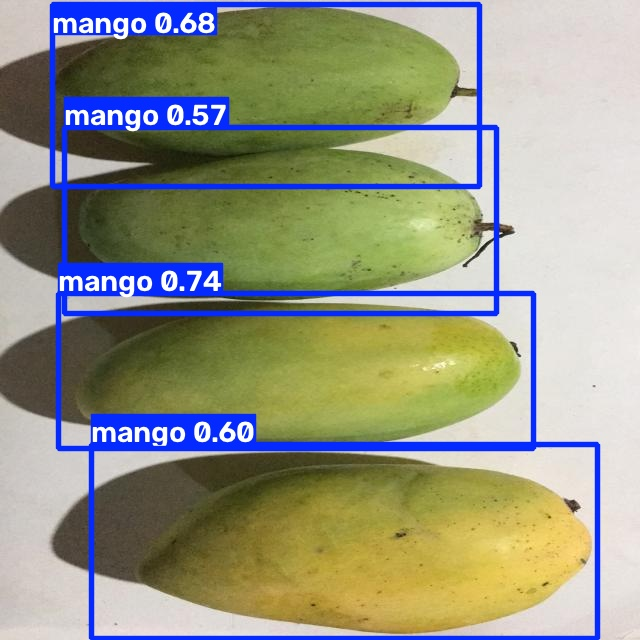


mango_mango_merged_dataset_000003_Mango Detection.v1i.yolov5pytorch_IMG_20240517_222249_017-Copy-2-_jpg.rf.06bf8ff320f12165ecf0d3b606fc885c_fb96ed90.jpg


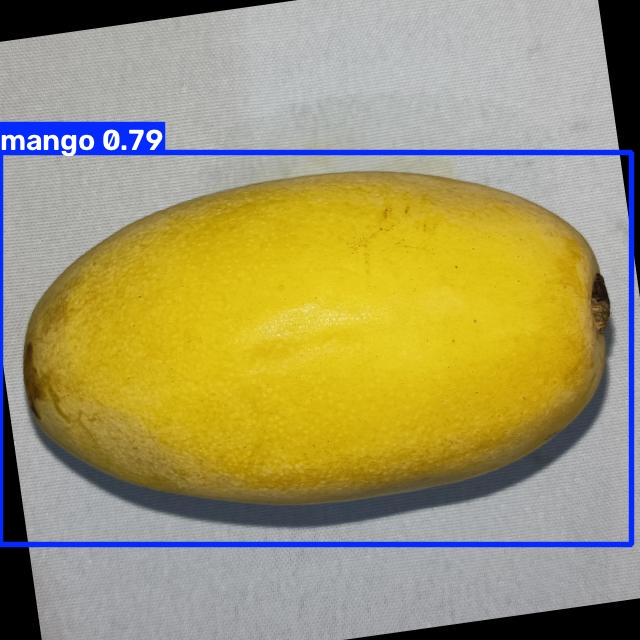


mango_mango_merged_dataset_000004_archive_combined_181_jpg.rf.9be22d95c6517397652cebe58d63baaf_ee0094b9.jpg


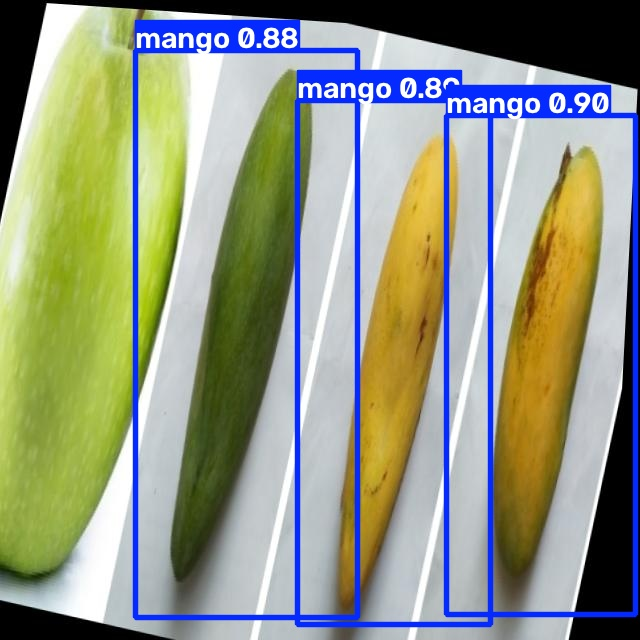


mango_mango_merged_dataset_000005_archive_IMG20200713145316_jpg.rf.fd3aeaa38e73f4a8c382fae9586e1e38_fb83078a.jpg


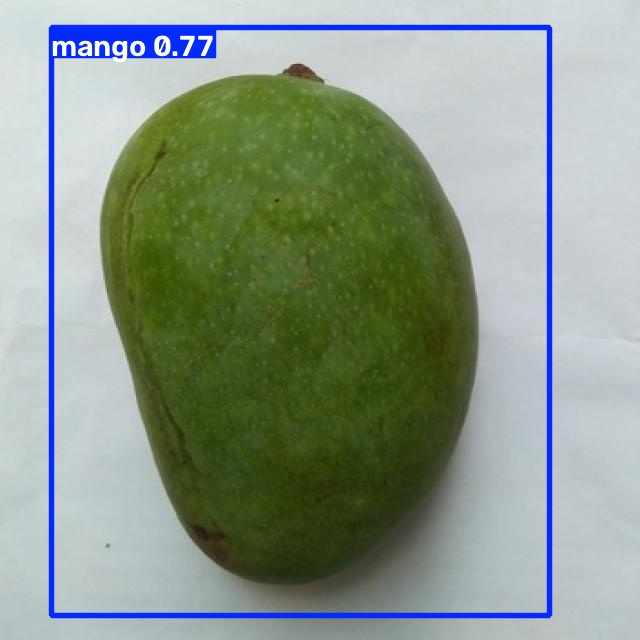

In [24]:
# ============================================================
# CELL 23: DISPLAY TEST PREDICTIONS
# ============================================================

from PIL import Image
from IPython.display import display


prediction_images = sorted(

    file

    for file
    in TEST_PREDICTIONS_DIR.iterdir()

    if (
        file.is_file()
        and file.suffix.lower()
        in IMAGE_EXTENSIONS
    )
)


print(
    f"Prediction images found: "
    f"{len(prediction_images)}"
)


# ------------------------------------------------------------
# Display a few images
# ------------------------------------------------------------

NUM_IMAGES_TO_DISPLAY = 5


for image_path in prediction_images[
    :NUM_IMAGES_TO_DISPLAY
]:

    print(
        f"\n{image_path.name}"
    )

    image = Image.open(
        image_path
    )

    display(
        image
    )

In [25]:
# ============================================================
# CELL 24: EVALUATION RESULTS
# ============================================================

TRAIN_RESULTS_DIR = (
    YOLOV5_DIR
    / "runs"
    / "train"
    / "fruit_detector"
)


VAL_RESULTS_DIR = (
    YOLOV5_DIR
    / "runs"
    / "val"
    / "validation"
)


TEST_RESULTS_DIR = (
    YOLOV5_DIR
    / "runs"
    / "test"
    / "final_test"
)


print("=" * 70)
print("RESULT LOCATIONS")
print("=" * 70)


print(
    "\nTraining:"
)

print(
    TRAIN_RESULTS_DIR.resolve()
)


print(
    "\nValidation:"
)

print(
    VAL_RESULTS_DIR.resolve()
)


print(
    "\nTest:"
)

print(
    TEST_RESULTS_DIR.resolve()
)


print(
    "\nPredictions:"
)

print(
    TEST_PREDICTIONS_DIR.resolve()
)

RESULT LOCATIONS

Training:
/content/yolov5/runs/train/fruit_detector

Validation:
/content/yolov5/runs/val/validation

Test:
/content/yolov5/runs/test/final_test

Predictions:
/content/yolov5/runs/detect/test_predictions


Training results:


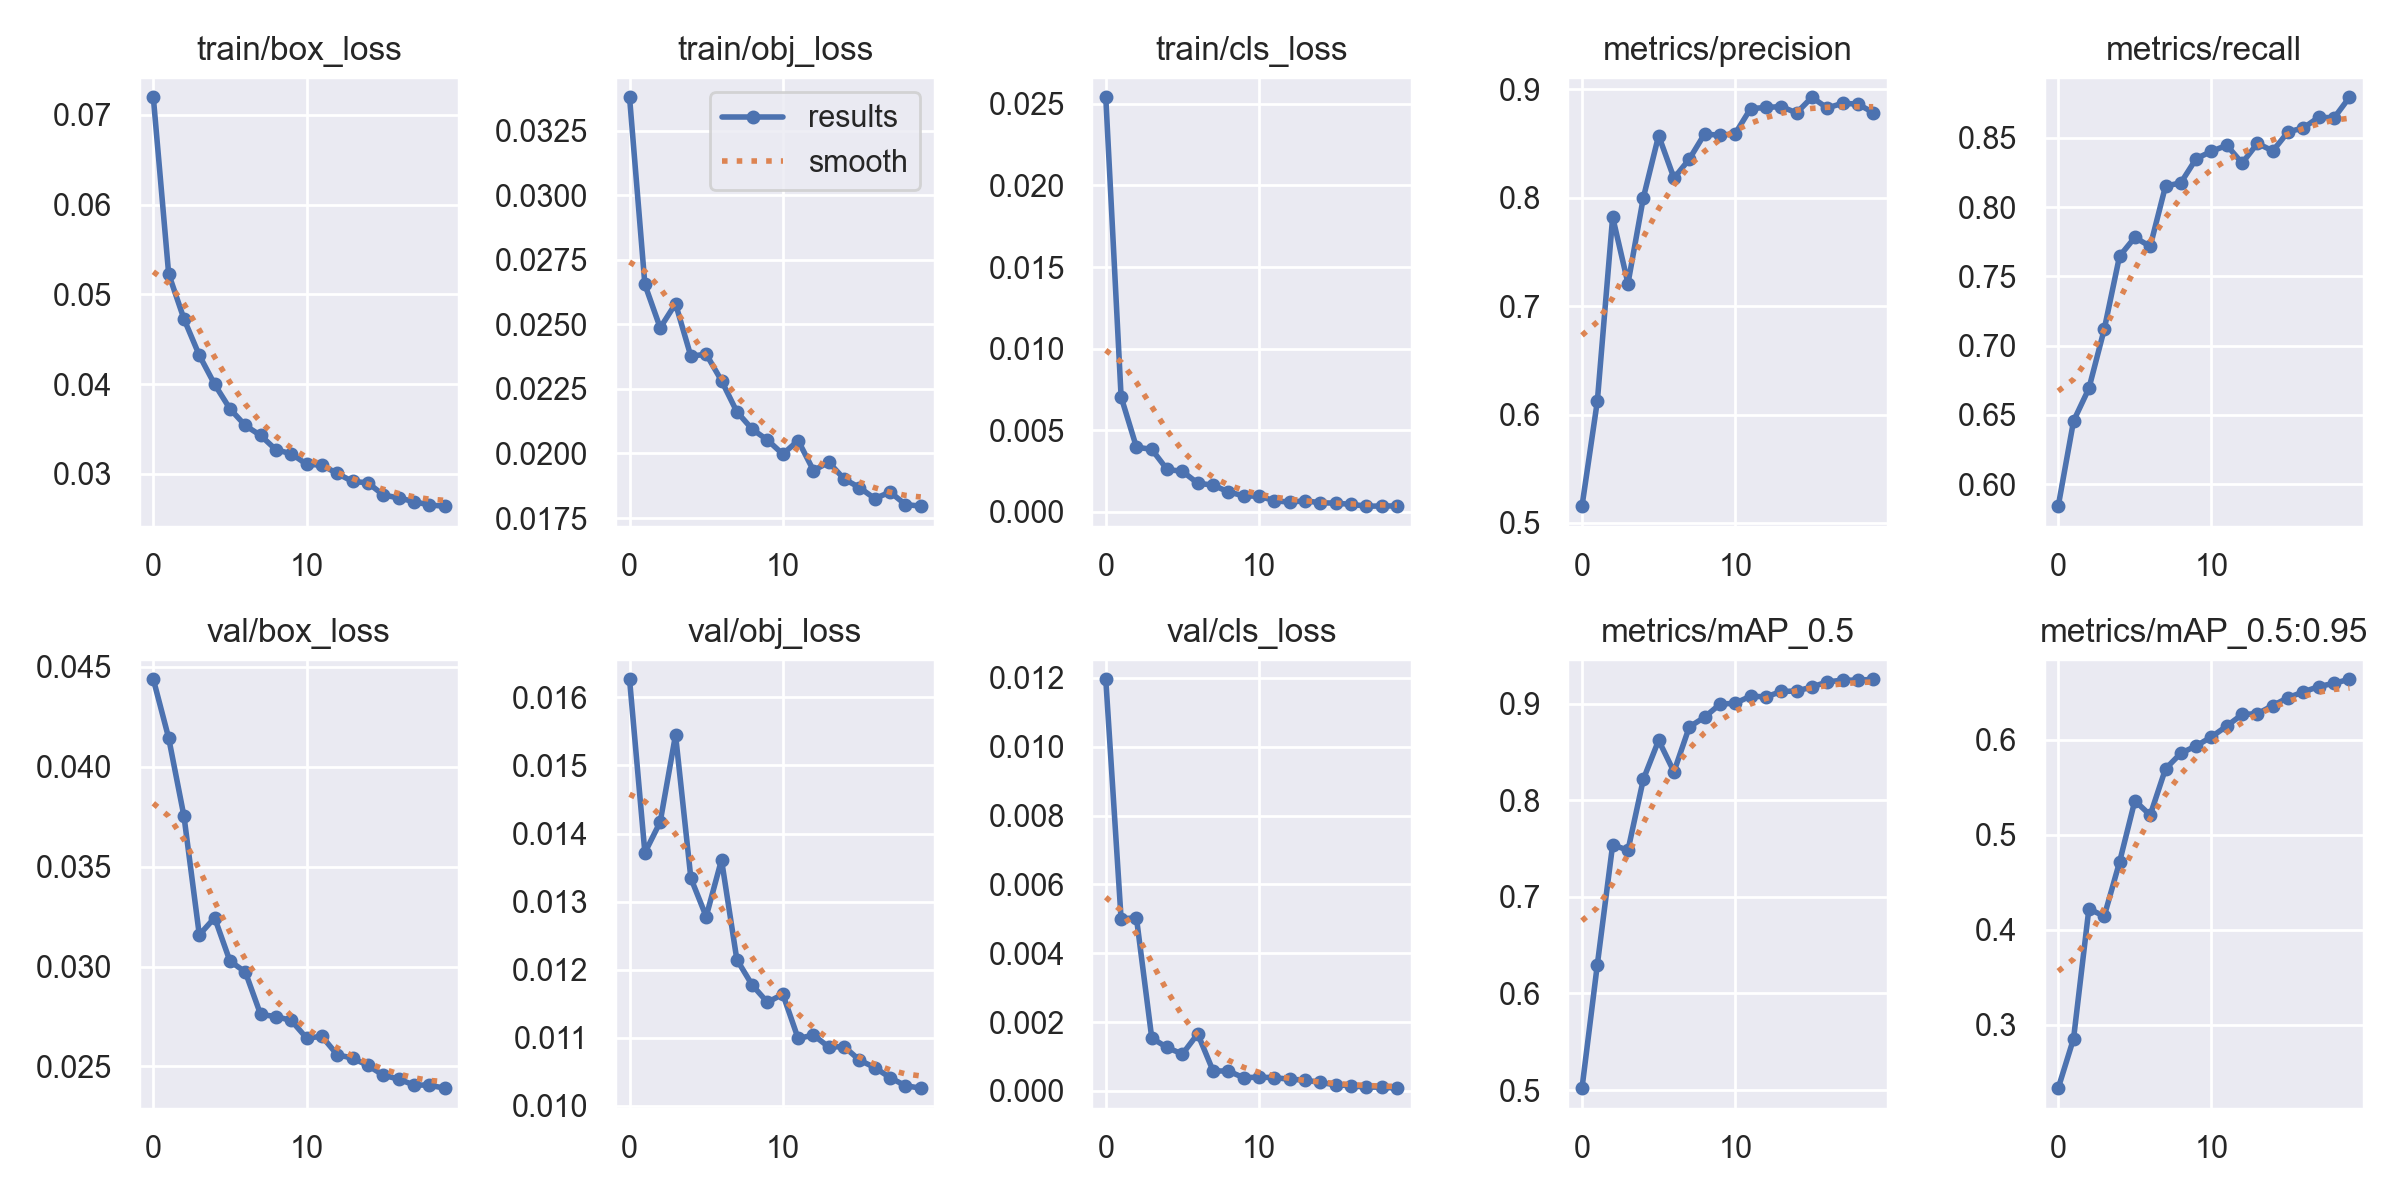

In [26]:
# ============================================================
# CELL 25: DISPLAY TRAINING RESULTS
# ============================================================

from PIL import Image
from IPython.display import display


results_plot = (
    TRAIN_RESULTS_DIR
    / "results.png"
)


if results_plot.exists():

    print(
        "Training results:"
    )

    display(
        Image.open(
            results_plot
        )
    )

else:

    print(
        "results.png was not found."
    )

Test confusion matrix:


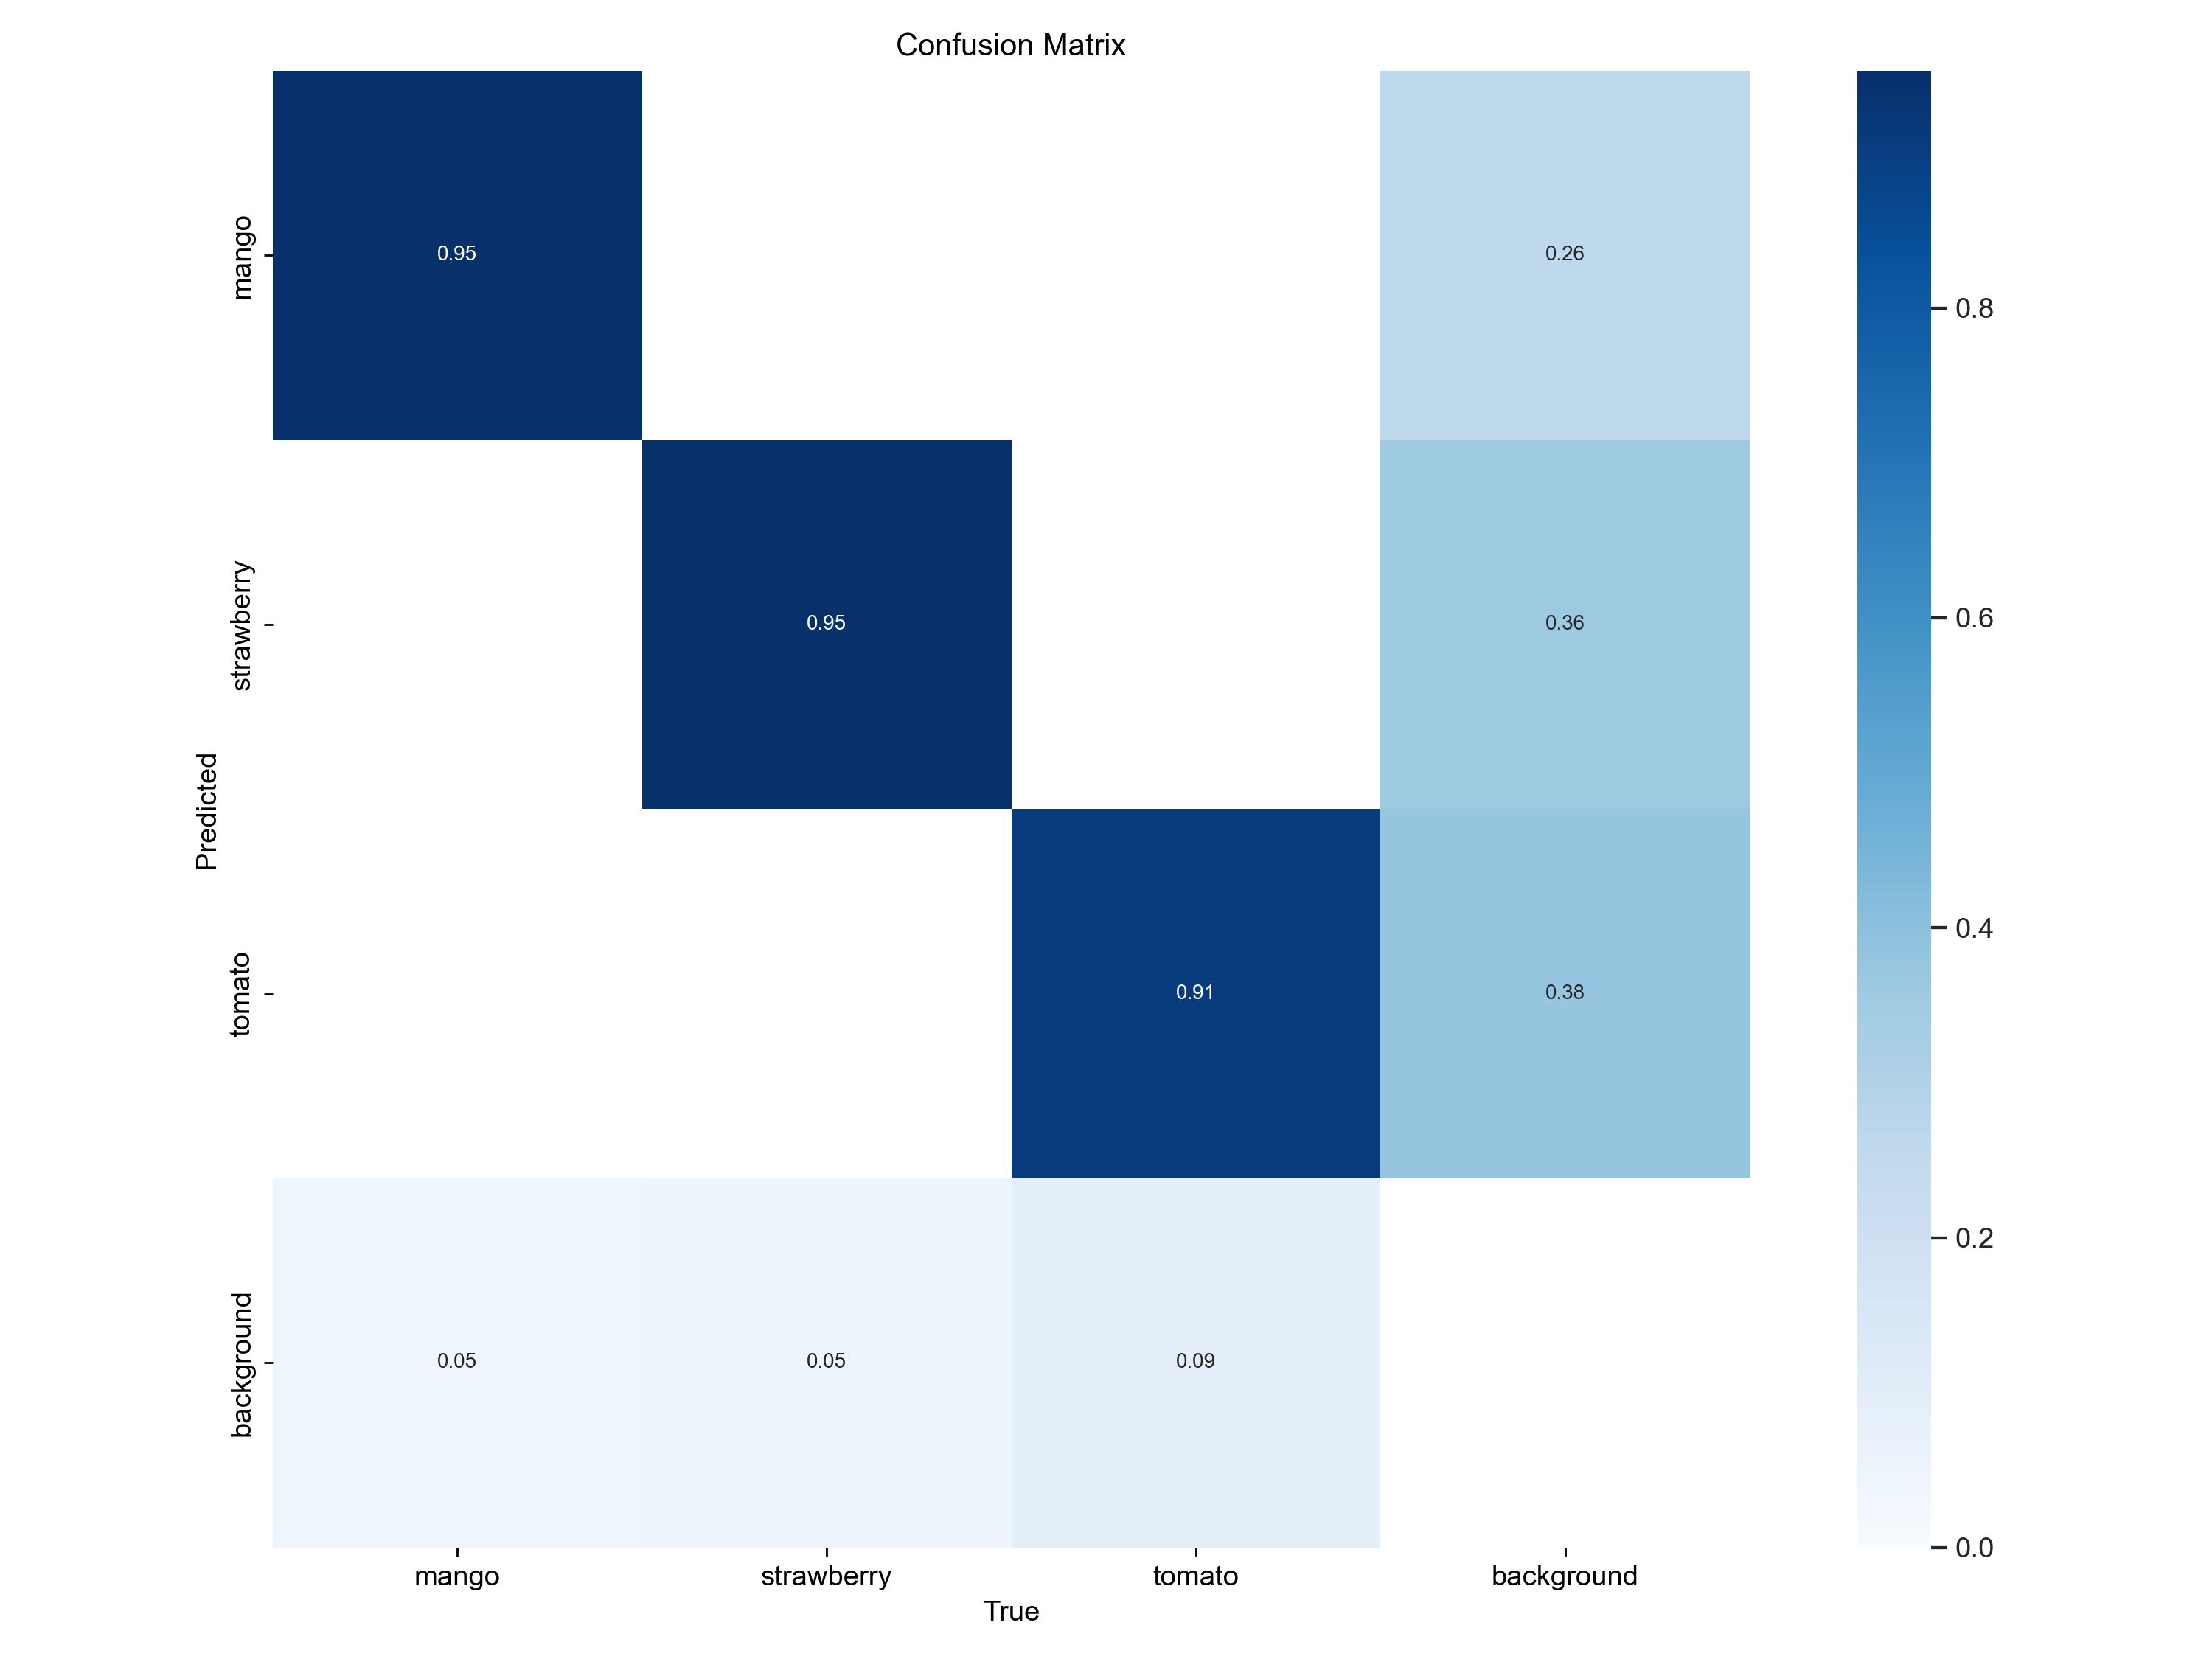

In [27]:
# ============================================================
# CELL 26: DISPLAY CONFUSION MATRIX
# ============================================================

confusion_matrix = (
    TEST_RESULTS_DIR
    / "confusion_matrix.png"
)


if confusion_matrix.exists():

    print(
        "Test confusion matrix:"
    )

    display(
        Image.open(
            confusion_matrix
        )
    )

else:

    print(
        "Confusion matrix was not found."
    )


PR_curve.png


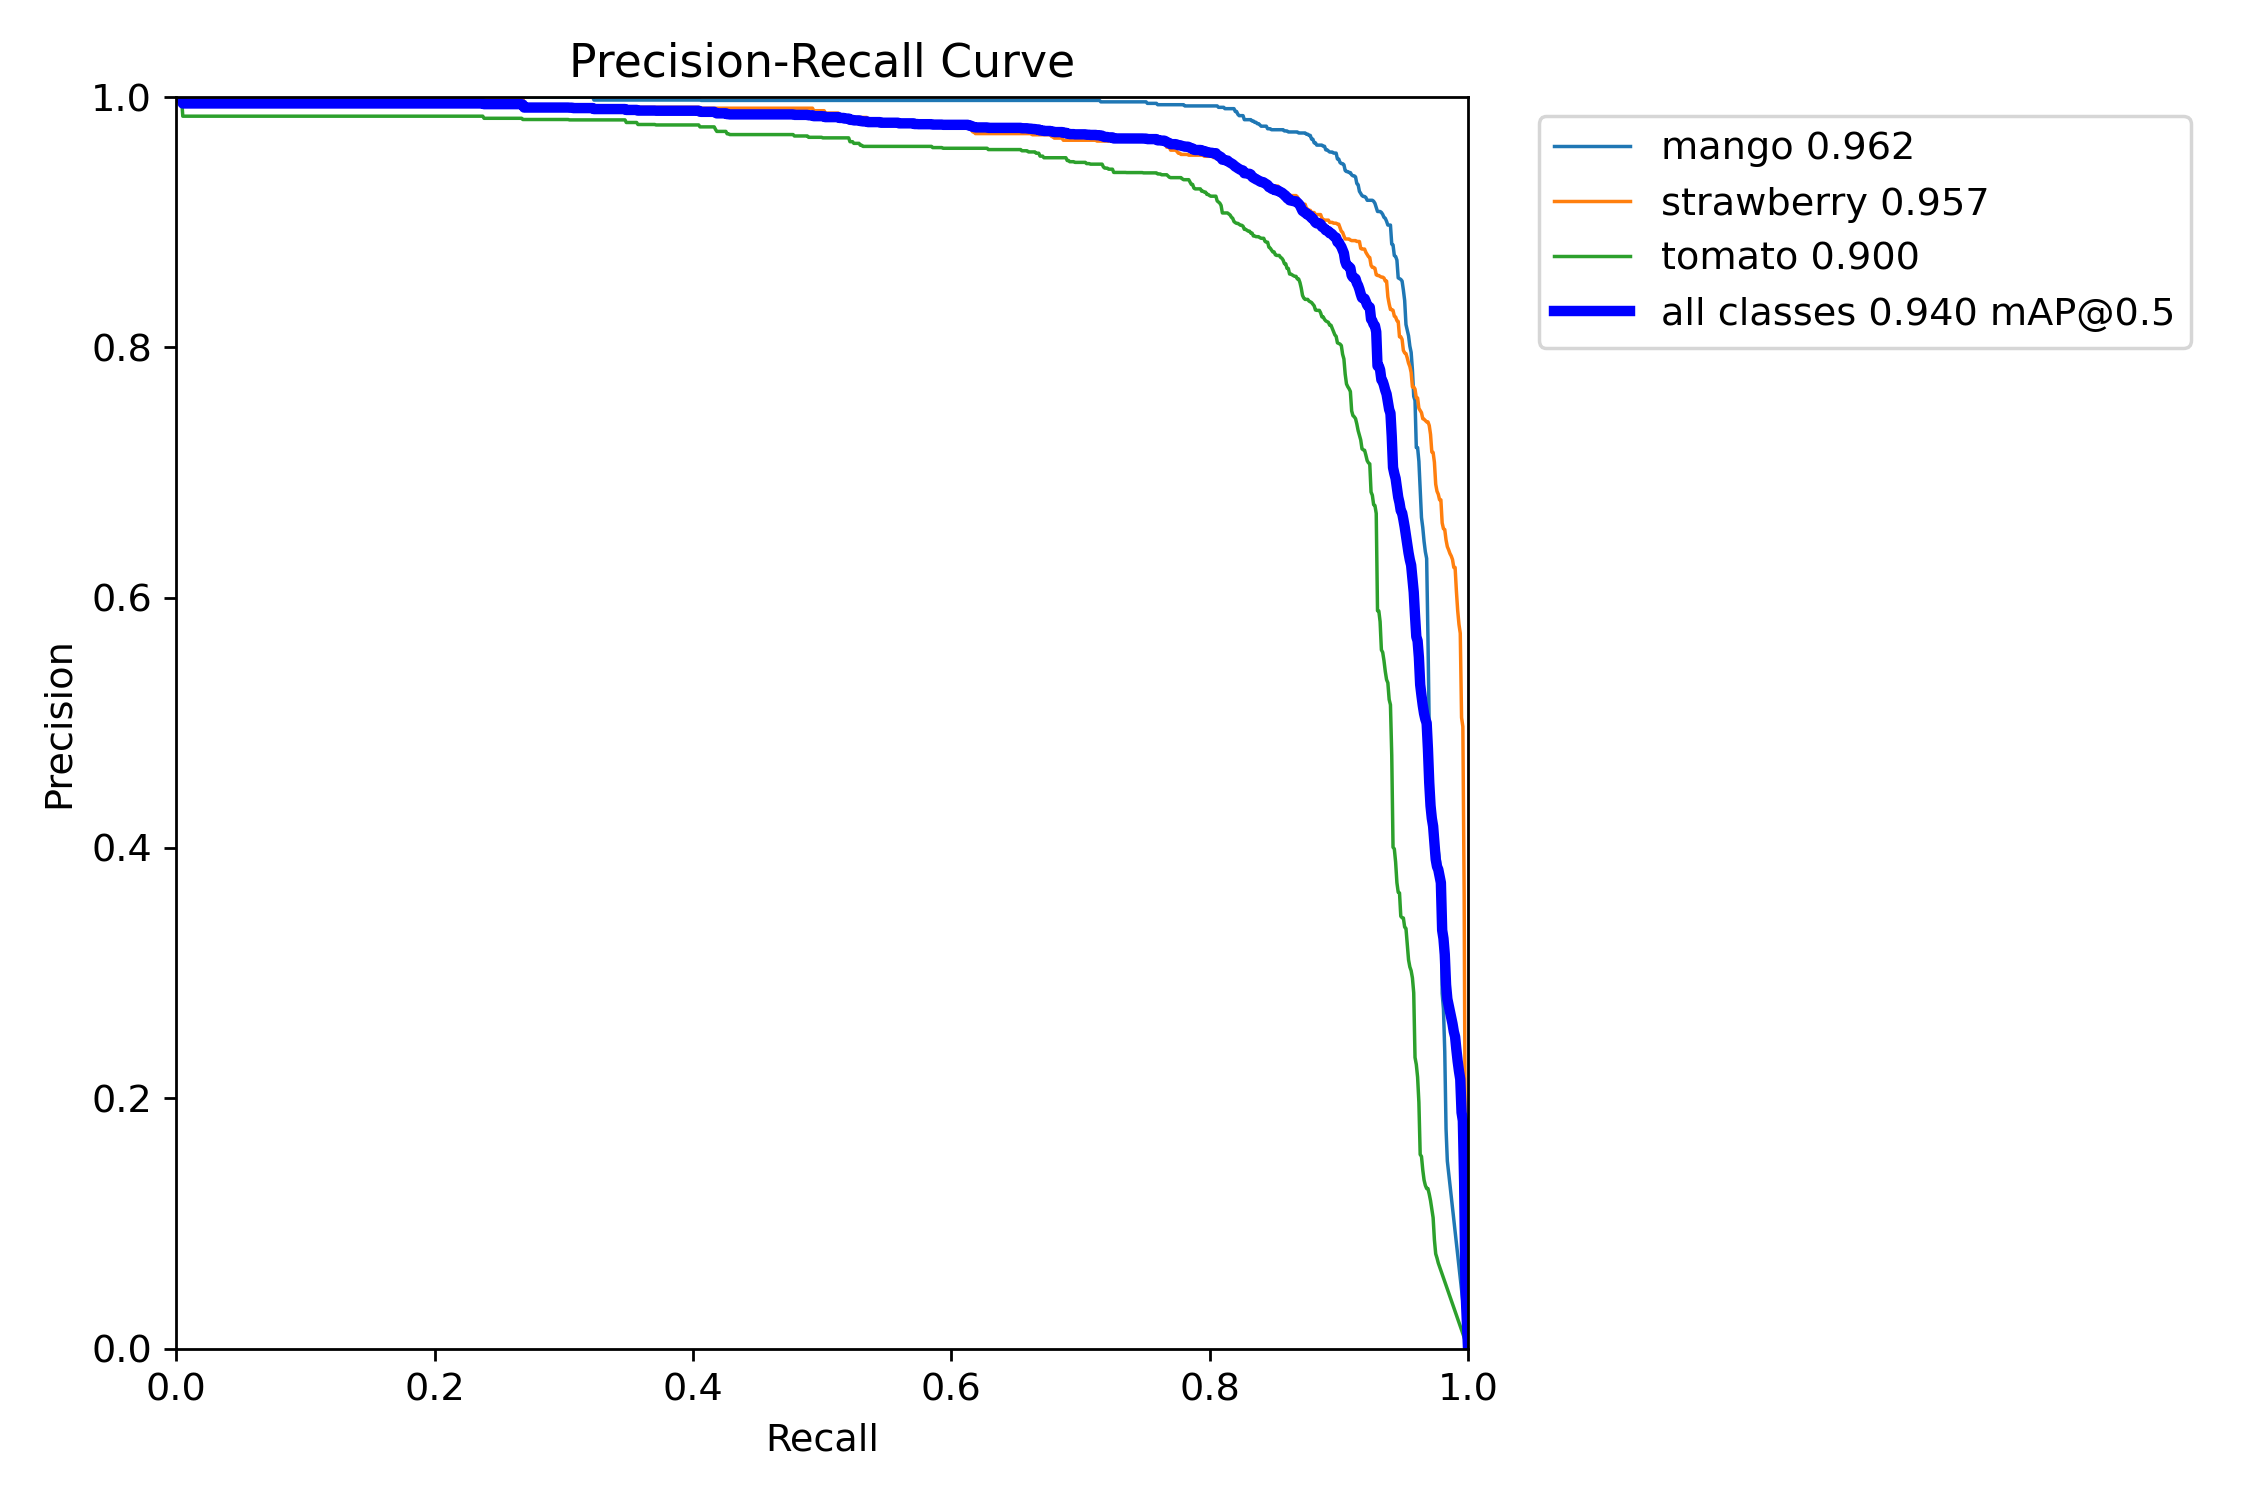


F1_curve.png


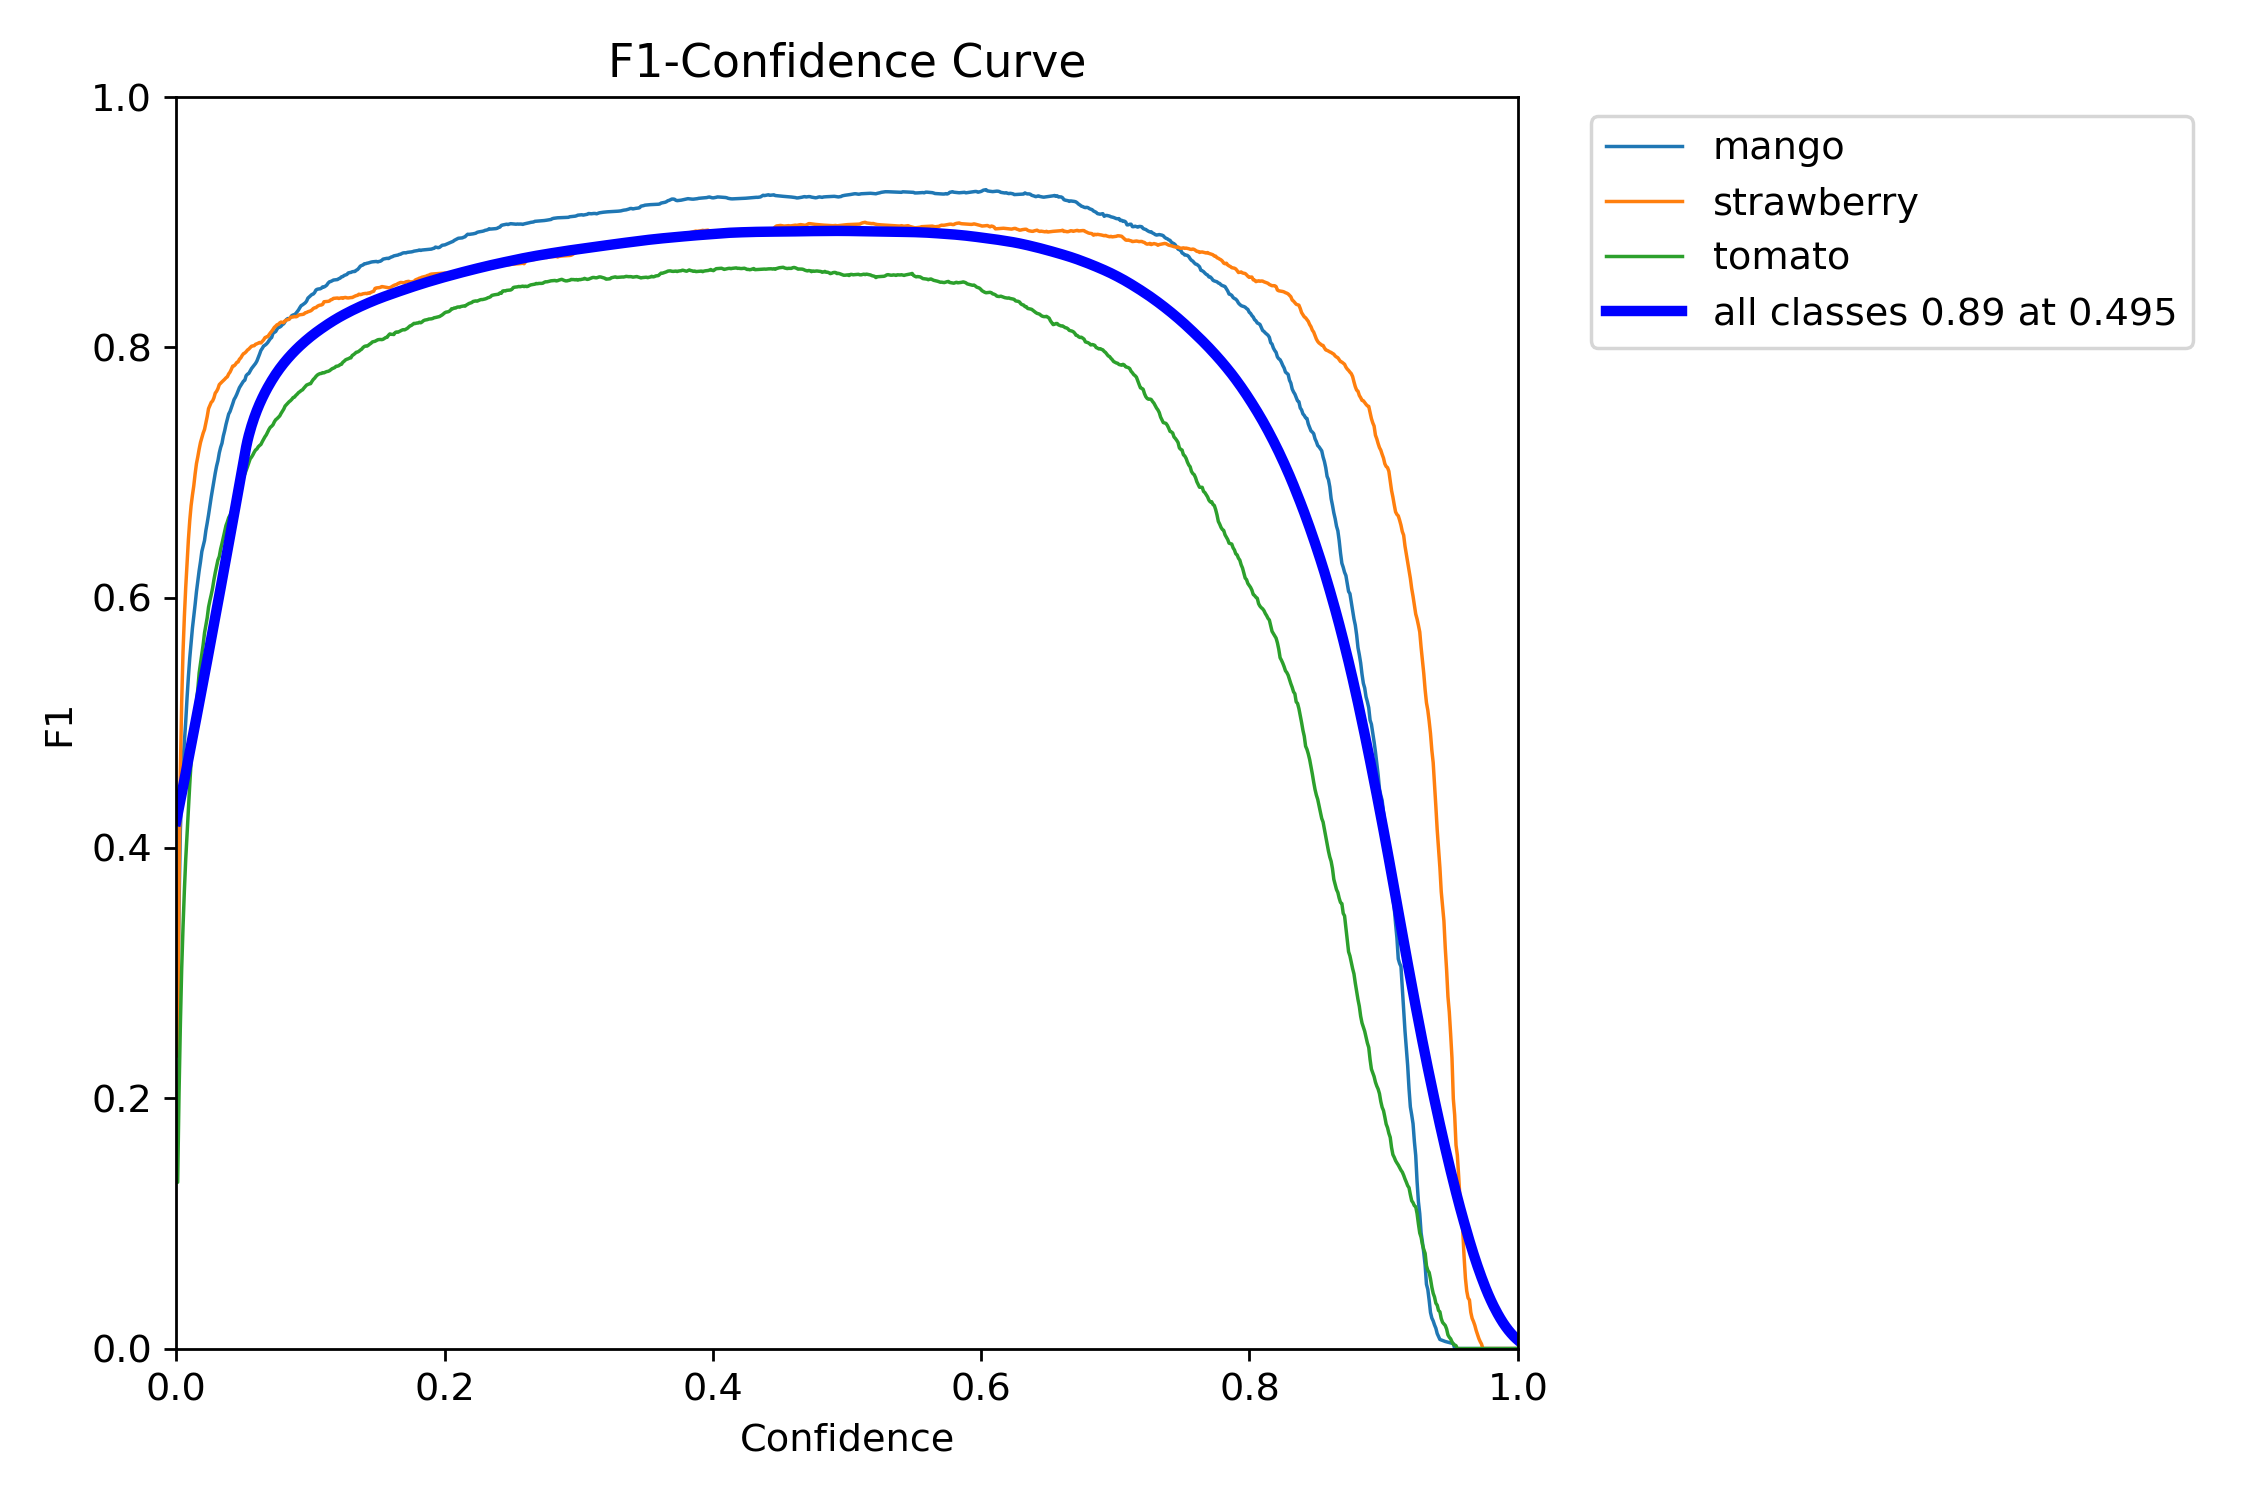


P_curve.png


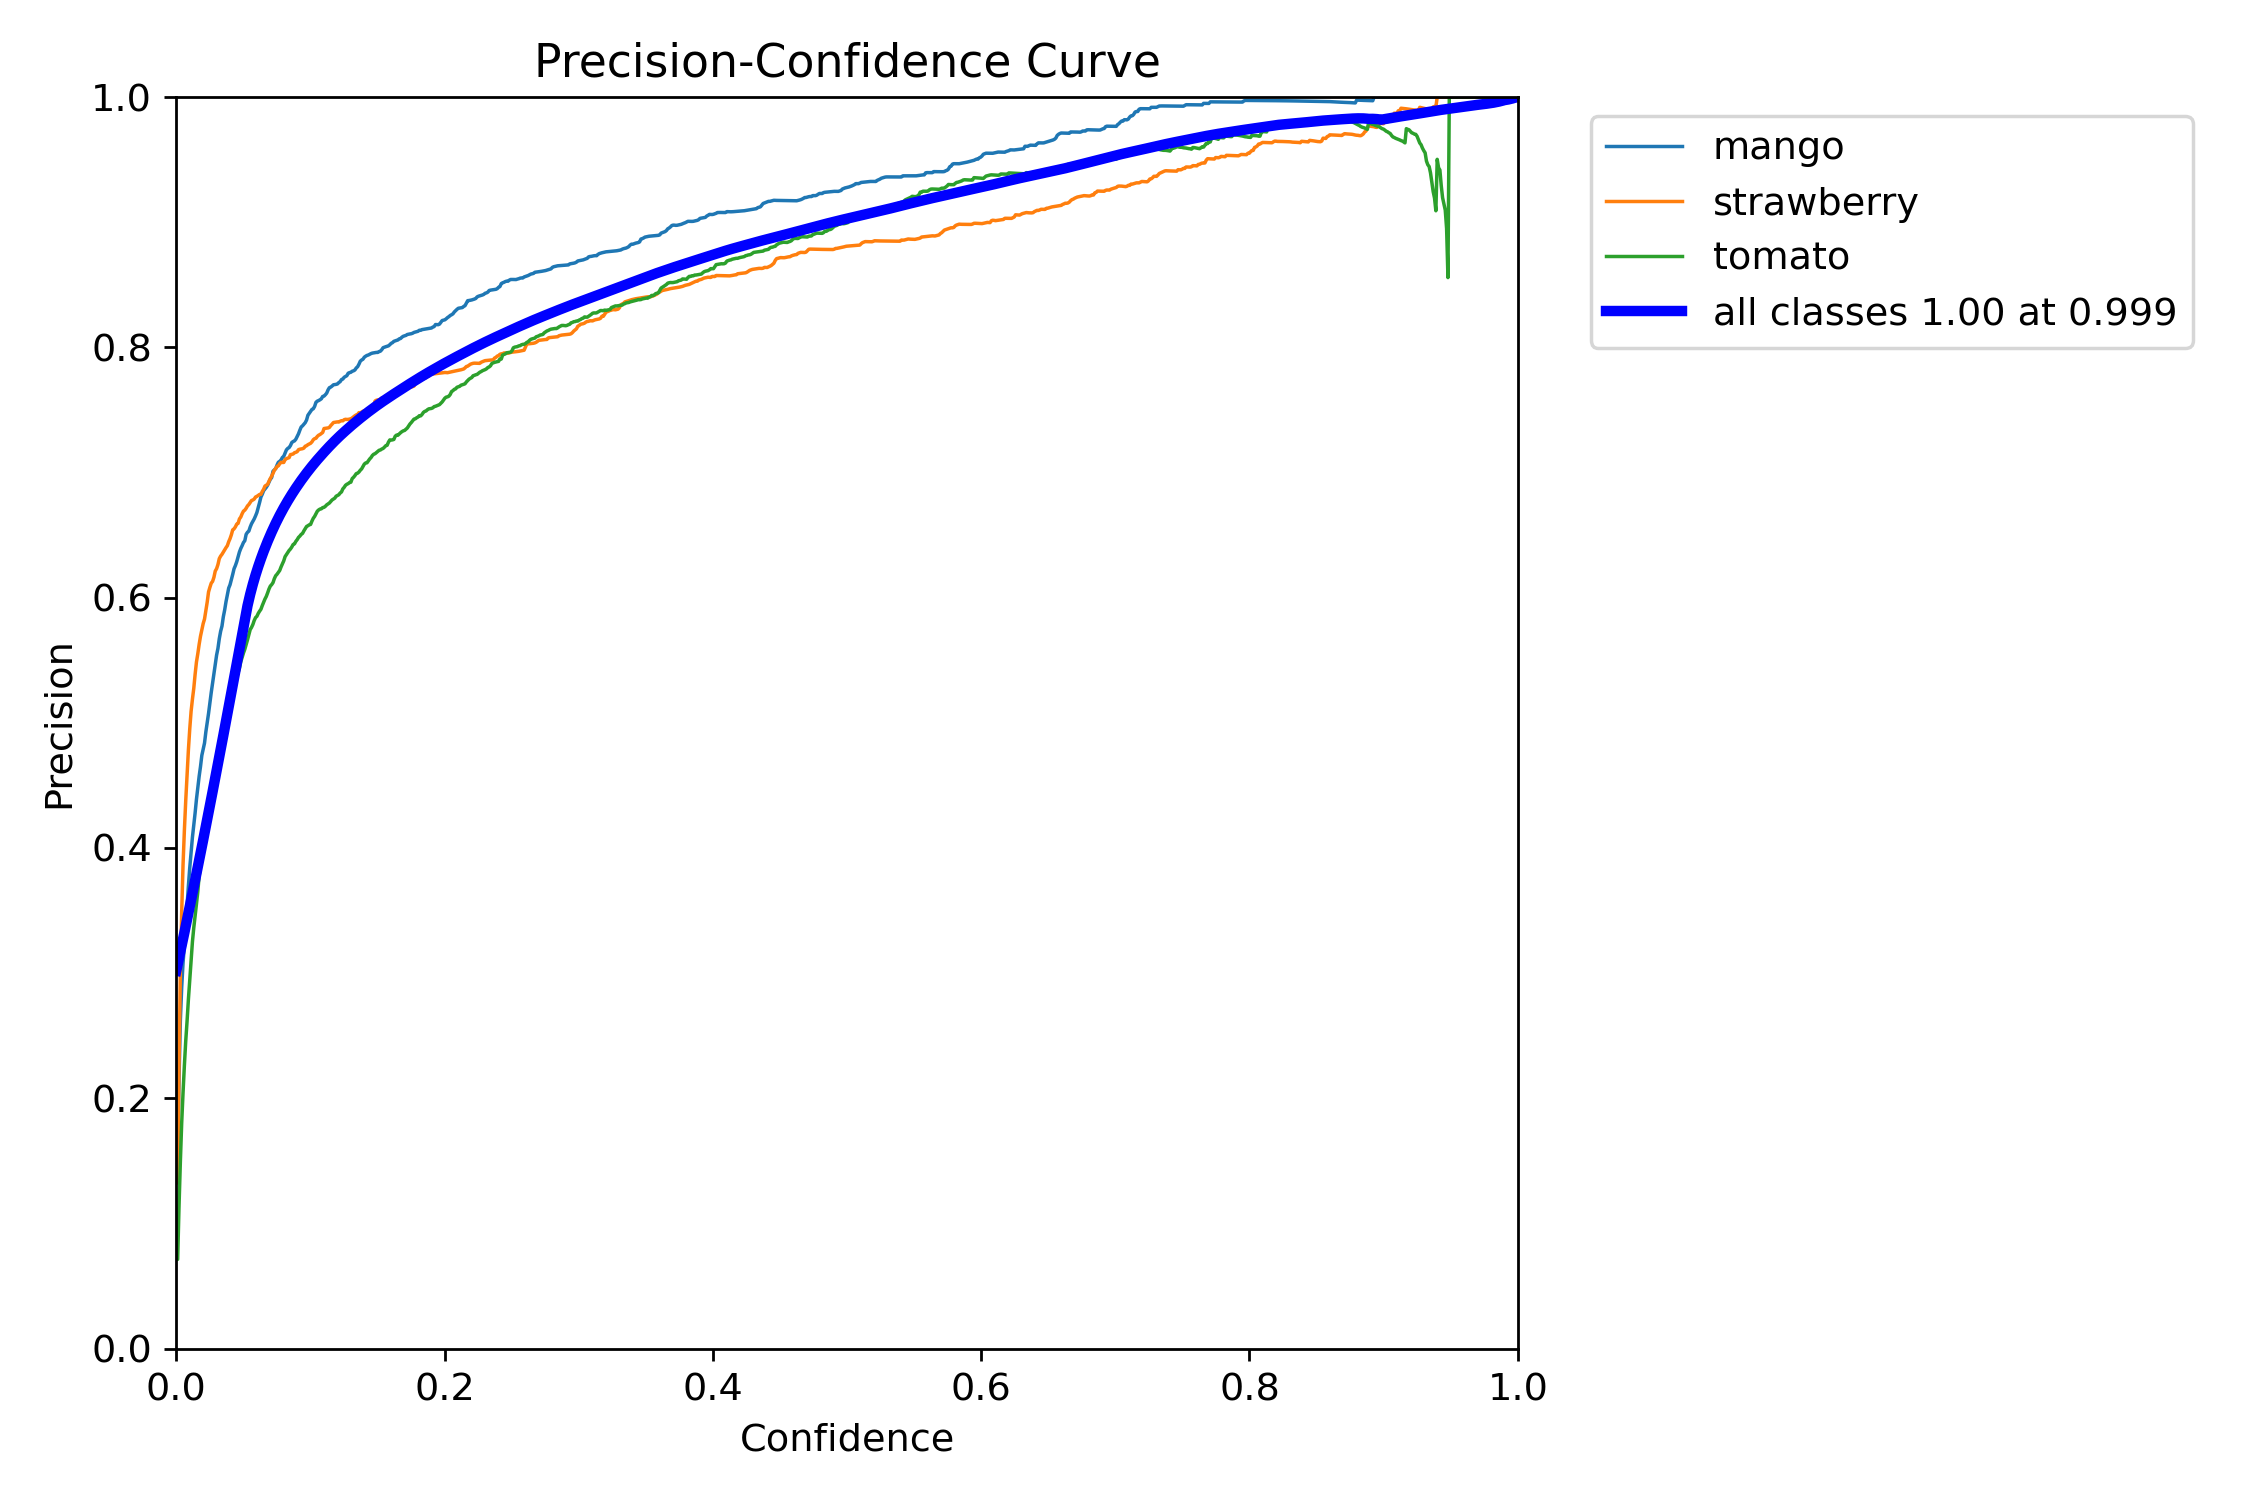


R_curve.png


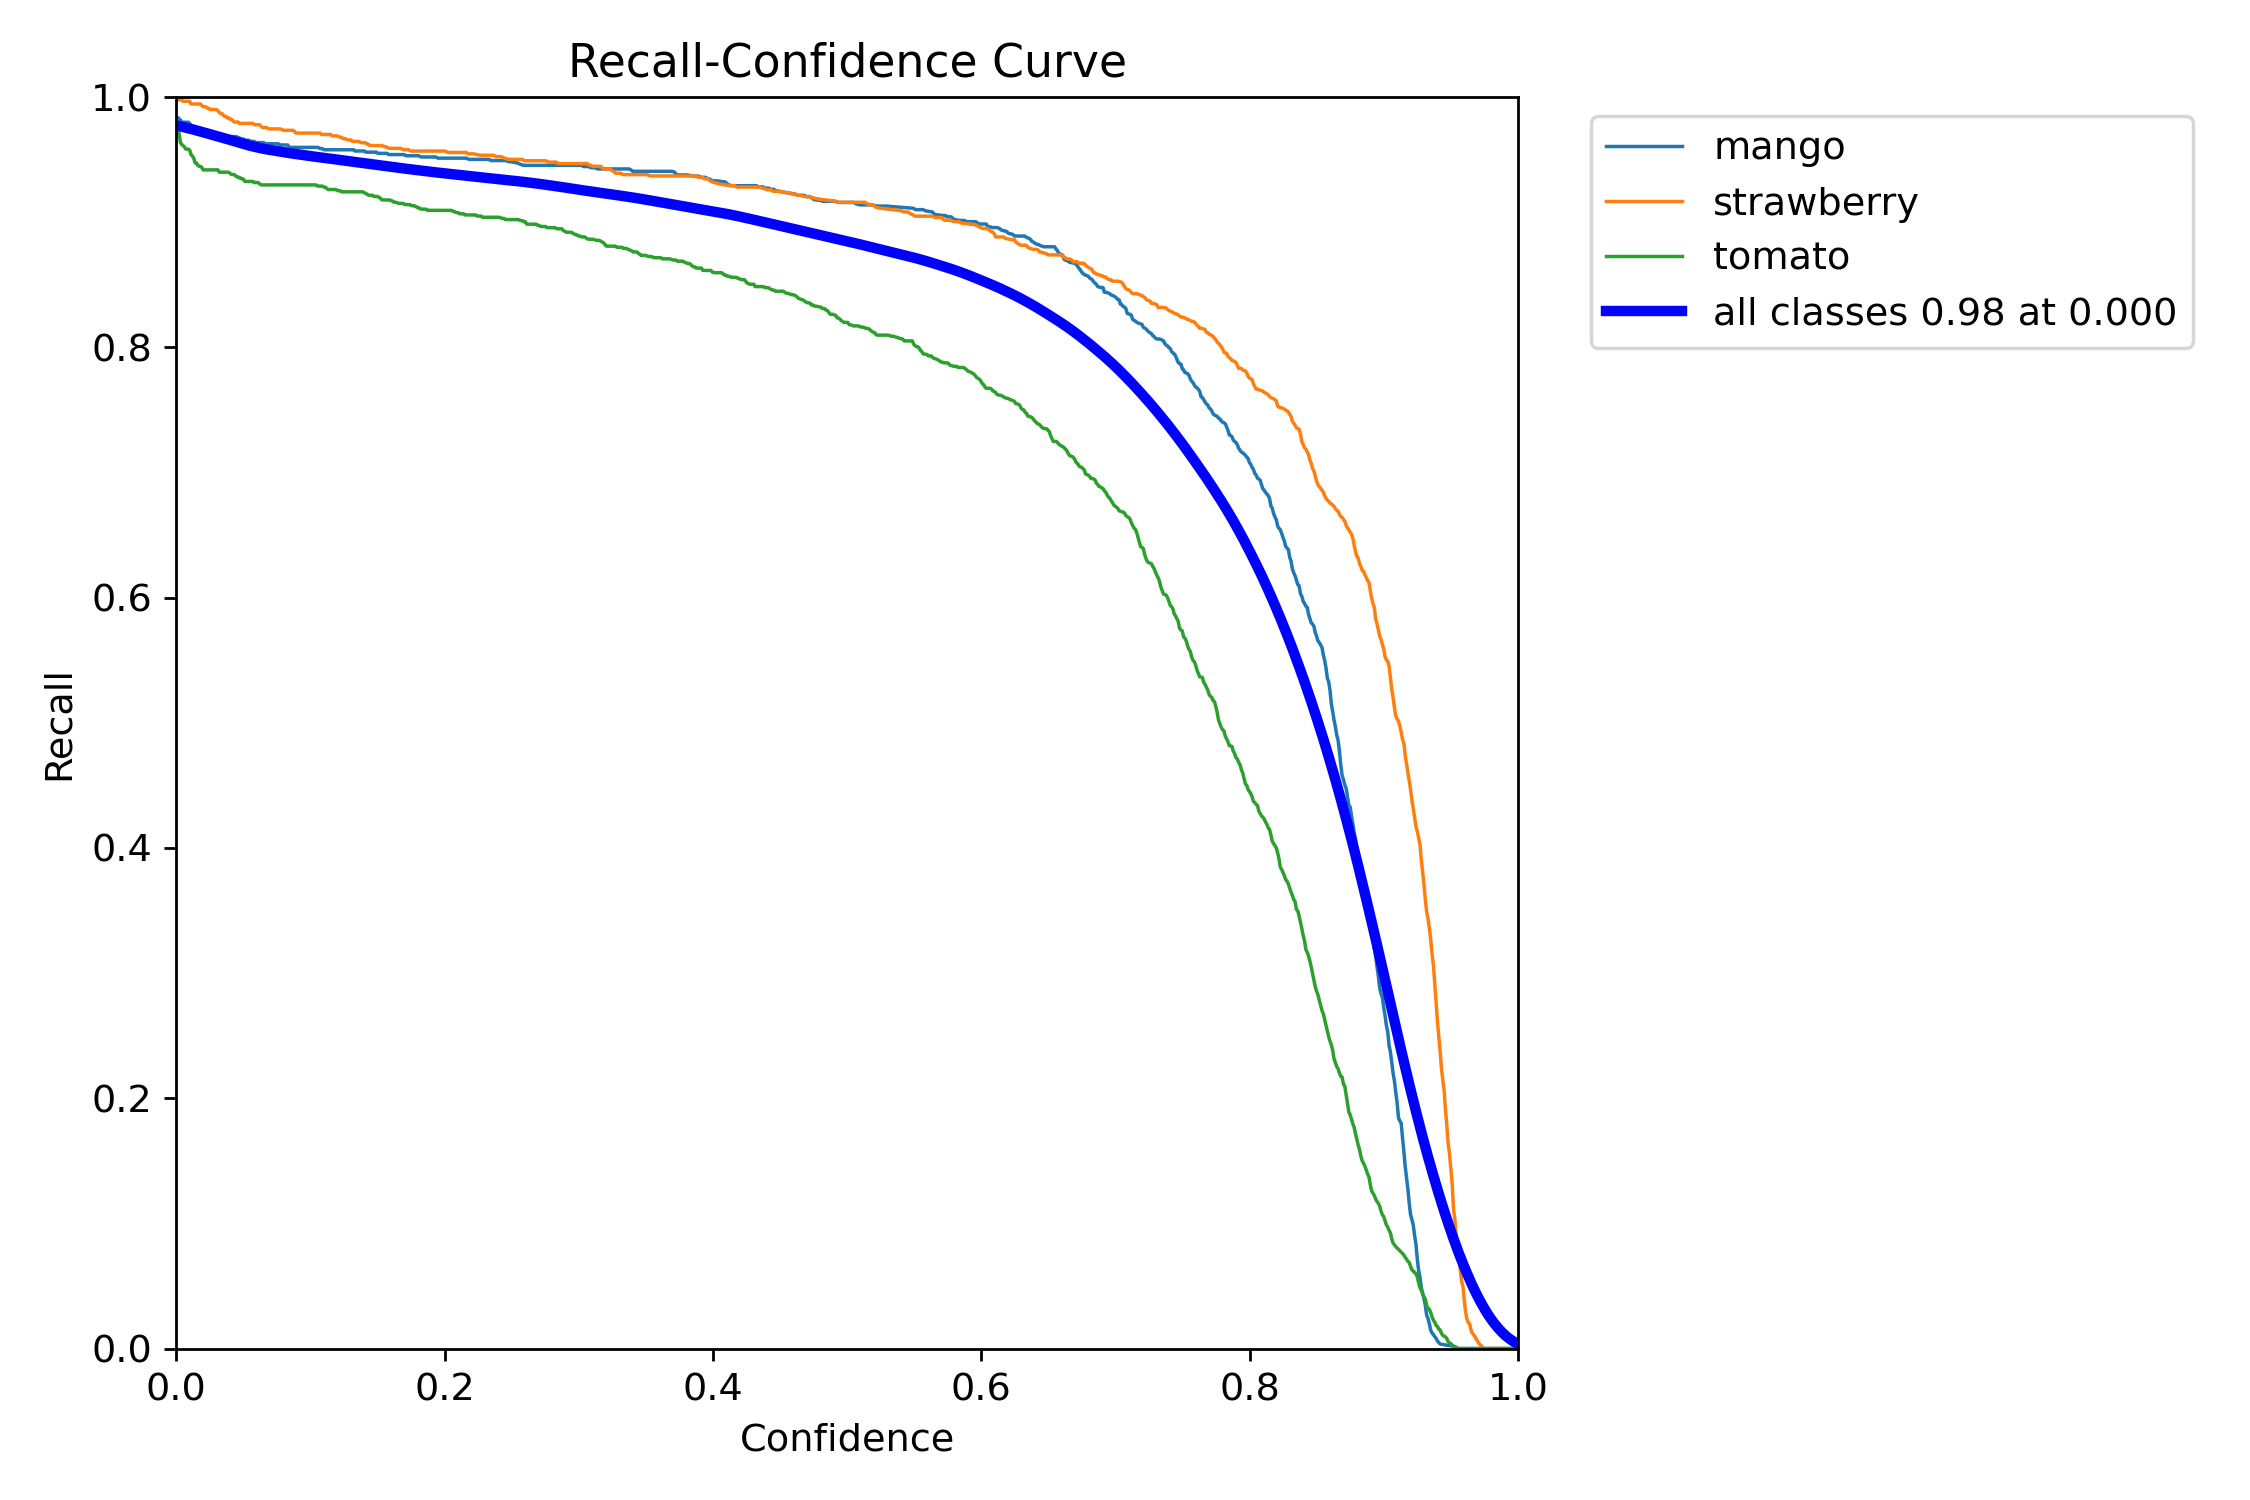

In [28]:
# ============================================================
# CELL 27: DISPLAY PR / F1 CURVES
# ============================================================

curve_files = [
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]


for filename in curve_files:

    file_path = (
        TEST_RESULTS_DIR
        / filename
    )

    if file_path.exists():

        print(
            f"\n{filename}"
        )

        display(
            Image.open(
                file_path
            )
        )

    else:

        print(
            f"{filename} not found."
        )

In [29]:
# ============================================================
# CELL 28: BACKUP RESULTS TO GOOGLE DRIVE
# ============================================================

import shutil


if DRIVE_RESULTS_DIR.exists():

    print(
        "Removing previous Drive backup..."
    )

    shutil.rmtree(
        DRIVE_RESULTS_DIR
    )


DRIVE_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Copy best.pt
# ------------------------------------------------------------

BEST_MODEL_DEST = (
    DRIVE_RESULTS_DIR
    / "best.pt"
)


shutil.copy2(
    BEST_MODEL,
    BEST_MODEL_DEST
)


# ------------------------------------------------------------
# Copy last.pt
# ------------------------------------------------------------

if LAST_MODEL.exists():

    shutil.copy2(
        LAST_MODEL,
        DRIVE_RESULTS_DIR
        / "last.pt"
    )


# ------------------------------------------------------------
# Copy complete training results
# ------------------------------------------------------------

drive_train_results = (
    DRIVE_RESULTS_DIR
    / "training_run"
)


shutil.copytree(
    TRAIN_RESULTS_DIR,
    drive_train_results,
    dirs_exist_ok=True
)


# ------------------------------------------------------------
# Copy validation results
# ------------------------------------------------------------

if VAL_RESULTS_DIR.exists():

    shutil.copytree(
        VAL_RESULTS_DIR,

        DRIVE_RESULTS_DIR
        / "validation",

        dirs_exist_ok=True
    )


# ------------------------------------------------------------
# Copy test results
# ------------------------------------------------------------

if TEST_RESULTS_DIR.exists():

    shutil.copytree(
        TEST_RESULTS_DIR,

        DRIVE_RESULTS_DIR
        / "test",

        dirs_exist_ok=True
    )


# ------------------------------------------------------------
# Copy predictions
# ------------------------------------------------------------

if TEST_PREDICTIONS_DIR.exists():

    shutil.copytree(
        TEST_PREDICTIONS_DIR,

        DRIVE_RESULTS_DIR
        / "test_predictions",

        dirs_exist_ok=True
    )


print(
    "\n✓ Results backed up to:"
)

print(
    DRIVE_RESULTS_DIR.resolve()
)


✓ Results backed up to:
/content/drive/MyDrive/Datasets/yolov5_results


In [30]:
# ============================================================
# CELL 29: FINAL EXPERIMENT SUMMARY
# ============================================================

print("=" * 75)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 75)


print(
    "\nDataset:"
)

print(
    dataset_root.resolve()
)


print(
    "\nClasses:"
)

for class_id, name in enumerate(
    class_names
):

    print(
        f"  {class_id}: {name}"
    )


print(
    "\nTraining configuration:"
)

print(
    f"  Model:       {MODEL_WEIGHTS}"
)

print(
    f"  Epochs:      {EPOCHS}"
)

print(
    f"  Batch size:  {BATCH_SIZE}"
)

print(
    f"  Image size:  {IMG_SIZE}"
)

print(
    f"  Optimizer:   {OPTIMIZER}"
)

print(
    f"  Seed:        {SEED}"
)


print(
    "\nGPU:"
)

print(
    torch.cuda.get_device_name(0)
)


print(
    "\nBest model:"
)

print(
    BEST_MODEL.resolve()
)


print(
    "\nDrive backup:"
)

print(
    DRIVE_RESULTS_DIR.resolve()
)


print("\n" + "=" * 75)
print("PIPELINE COMPLETE")
print("=" * 75)

FINAL EXPERIMENT SUMMARY

Dataset:
/content/dataset/extracted/final_dataset

Classes:
  0: mango
  1: strawberry
  2: tomato

Training configuration:
  Model:       yolov5s.pt
  Epochs:      20
  Batch size:  32
  Image size:  640
  Optimizer:   SGD
  Seed:        42

GPU:
Tesla T4

Best model:
/content/yolov5/runs/train/fruit_detector/weights/best.pt

Drive backup:
/content/drive/MyDrive/Datasets/yolov5_results

PIPELINE COMPLETE


In [31]:
# ============================================================
# CELL: SAVE EXPERIMENT TO GOOGLE DRIVE
# ============================================================
#
# This cell saves the COMPLETE experiment permanently to
# Google Drive.
#
# Each experiment gets its own folder.
#
# Example:
#
# Google Drive/
# └── AI_Project/
#     └── YOLOv5_Experiments/
#         └── yolov5s_640_bs16_50ep/
#             ├── weights/
#             │   ├── best.pt
#             │   └── last.pt
#             │
#             ├── training/
#             ├── validation/
#             ├── test/
#             ├── test_predictions/
#             ├── data_yolov5.yaml
#             └── hyperparameters.yaml
#
# ============================================================


from pathlib import Path
import shutil


# ============================================================
# 1. EXPERIMENT NAME
# ============================================================
#
# CHANGE THIS FOR EVERY NEW EXPERIMENT.
#
# Examples:
#
# yolov5s_640_bs16_50ep
# yolov5s_640_bs16_100ep
# yolov5m_640_bs16_50ep
# yolov5s_768_bs16_50ep
#
# Recommended naming:
#
# MODEL_IMAGE_SIZE_BATCH_EPOCHS
#
# ============================================================

EXPERIMENT_NAME = (
    "yolov5s_640_bs16_50ep"
)


# ============================================================
# 2. GOOGLE DRIVE OUTPUT LOCATION
# ============================================================

DRIVE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/Datasets"
)


DRIVE_EXPERIMENTS_DIR = (
    DRIVE_PROJECT_DIR
    / "YOLOv5_Experiments"
)


DRIVE_EXPERIMENT_DIR = (
    DRIVE_EXPERIMENTS_DIR
    / EXPERIMENT_NAME
)


# ============================================================
# 3. CREATE EXPERIMENT DIRECTORY
# ============================================================

DRIVE_EXPERIMENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Experiment directory:"
)

print(
    DRIVE_EXPERIMENT_DIR
)


# ============================================================
# 4. LOCAL YOLOV5 RESULT DIRECTORIES
# ============================================================

TRAIN_RESULTS_DIR = (
    YOLOV5_DIR
    / "runs"
    / "train"
    / "fruit_detector"
)


VAL_RESULTS_DIR = (
    YOLOV5_DIR
    / "runs"
    / "val"
    / "validation"
)


TEST_RESULTS_DIR = (
    YOLOV5_DIR
    / "runs"
    / "test"
    / "final_test"
)


PREDICTIONS_DIR = (
    YOLOV5_DIR
    / "runs"
    / "detect"
    / "test_predictions"
)


# ============================================================
# 5. COPY TRAINING RESULTS
# ============================================================

if TRAIN_RESULTS_DIR.exists():

    shutil.copytree(

        TRAIN_RESULTS_DIR,

        DRIVE_EXPERIMENT_DIR
        / "training",

        dirs_exist_ok=True
    )

    print(
        "✓ Training results copied."
    )

else:

    print(
        "⚠ Training results not found."
    )


# ============================================================
# 6. COPY VALIDATION RESULTS
# ============================================================

if VAL_RESULTS_DIR.exists():

    shutil.copytree(

        VAL_RESULTS_DIR,

        DRIVE_EXPERIMENT_DIR
        / "validation",

        dirs_exist_ok=True
    )

    print(
        "✓ Validation results copied."
    )

else:

    print(
        "⚠ Validation results not found."
    )


# ============================================================
# 7. COPY FINAL TEST RESULTS
# ============================================================

if TEST_RESULTS_DIR.exists():

    shutil.copytree(

        TEST_RESULTS_DIR,

        DRIVE_EXPERIMENT_DIR
        / "test",

        dirs_exist_ok=True
    )

    print(
        "✓ Test results copied."
    )

else:

    print(
        "⚠ Test results not found."
    )


# ============================================================
# 8. COPY TEST PREDICTIONS
# ============================================================

if PREDICTIONS_DIR.exists():

    shutil.copytree(

        PREDICTIONS_DIR,

        DRIVE_EXPERIMENT_DIR
        / "test_predictions",

        dirs_exist_ok=True
    )

    print(
        "✓ Test predictions copied."
    )

else:

    print(
        "⚠ Test predictions not found."
    )


# ============================================================
# 9. COPY MODEL WEIGHTS
# ============================================================

BEST_MODEL = (
    TRAIN_RESULTS_DIR
    / "weights"
    / "best.pt"
)


LAST_MODEL = (
    TRAIN_RESULTS_DIR
    / "weights"
    / "last.pt"
)


DRIVE_WEIGHTS_DIR = (
    DRIVE_EXPERIMENT_DIR
    / "weights"
)


DRIVE_WEIGHTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# best.pt
# ------------------------------------------------------------

if BEST_MODEL.exists():

    shutil.copy2(

        BEST_MODEL,

        DRIVE_WEIGHTS_DIR
        / "best.pt"
    )

    print(
        "✓ best.pt copied."
    )

else:

    print(
        "⚠ best.pt not found."
    )


# ------------------------------------------------------------
# last.pt
# ------------------------------------------------------------

if LAST_MODEL.exists():

    shutil.copy2(

        LAST_MODEL,

        DRIVE_WEIGHTS_DIR
        / "last.pt"
    )

    print(
        "✓ last.pt copied."
    )

else:

    print(
        "⚠ last.pt not found."
    )


# ============================================================
# 10. COPY DATASET YAML
# ============================================================

if YOLOV5_DATA_YAML.exists():

    shutil.copy2(

        YOLOV5_DATA_YAML,

        DRIVE_EXPERIMENT_DIR
        / "data_yolov5.yaml"
    )

    print(
        "✓ data_yolov5.yaml copied."
    )

else:

    print(
        "⚠ data_yolov5.yaml not found."
    )


# ============================================================
# 11. COPY CUSTOM HYPERPARAMETERS
# ============================================================

if (
    USE_CUSTOM_HYP
    and HYP_FILE.exists()
):

    shutil.copy2(

        HYP_FILE,

        DRIVE_EXPERIMENT_DIR
        / "hyperparameters.yaml"
    )

    print(
        "✓ hyperparameters.yaml copied."
    )


# ============================================================
# 12. SAVE EXPERIMENT CONFIGURATION
# ============================================================
#
# This creates a small text file recording exactly how the
# experiment was configured.
#
# This is very useful for your thesis/research work.
#
# ============================================================

config_text = f"""
YOLOv5 Experiment Configuration
================================

Experiment:
{EXPERIMENT_NAME}

Model:
{MODEL_WEIGHTS}

Epochs:
{EPOCHS}

Batch Size:
{BATCH_SIZE}

Image Size:
{IMG_SIZE}

Workers:
{WORKERS}

Optimizer:
{OPTIMIZER}



Custom Hyperparameters:
{USE_CUSTOM_HYP}

Random Seed:
{SEED}

GPU:
{torch.cuda.get_device_name(0)}

GPU Memory:
{torch.cuda.get_device_properties(0).total_memory / (1024 ** 3):.2f} GB

Number of Classes:
{NC}

Classes:
{class_names}

Dataset:
{dataset_root.resolve()}
"""


CONFIG_FILE = (
    DRIVE_EXPERIMENT_DIR
    / "experiment_config.txt"
)


with open(
    CONFIG_FILE,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        config_text.strip()
    )


print(
    "✓ experiment_config.txt saved."
)


# ============================================================
# 13. FINAL REPORT
# ============================================================

print("\n")
print("=" * 70)
print("EXPERIMENT BACKUP COMPLETE")
print("=" * 70)


print(
    "\nExperiment:"
)

print(
    EXPERIMENT_NAME
)


print(
    "\nSaved permanently to:"
)

print(
    DRIVE_EXPERIMENT_DIR
)


print(
    "\nContents:"
)

print(
    f"""
{EXPERIMENT_NAME}/
│
├── weights/
│   ├── best.pt
│   └── last.pt
│
├── training/
│
├── validation/
│
├── test/
│
├── test_predictions/
│
├── data_yolov5.yaml
│
├── hyperparameters.yaml
│       (if custom hyperparameters were used)
│
└── experiment_config.txt
"""
)

Experiment directory:
/content/drive/MyDrive/Datasets/YOLOv5_Experiments/yolov5s_640_bs16_50ep
✓ Training results copied.
✓ Validation results copied.
✓ Test results copied.
✓ Test predictions copied.
✓ best.pt copied.
✓ last.pt copied.
✓ data_yolov5.yaml copied.
✓ experiment_config.txt saved.


EXPERIMENT BACKUP COMPLETE

Experiment:
yolov5s_640_bs16_50ep

Saved permanently to:
/content/drive/MyDrive/Datasets/YOLOv5_Experiments/yolov5s_640_bs16_50ep

Contents:

yolov5s_640_bs16_50ep/
│
├── weights/
│   ├── best.pt
│   └── last.pt
│
├── training/
│
├── validation/
│
├── test/
│
├── test_predictions/
│
├── data_yolov5.yaml
│
├── hyperparameters.yaml
│       (if custom hyperparameters were used)
│
└── experiment_config.txt

